# SolarMedic AI
## Hierarchical Thermal Diagnosis and Maintenance Prioritization for Photovoltaic Modules

### Deep Learning Project — Infrared Image Classification

**Author:** Carla Bozintan  
**Course:** Deep Learning  
**Development Environment:** Visual Studio Code + Jupyter Notebook  
**Dataset:** Infrared Solar Modules — Raptor Maps / Kaggle  

---

### Project Overview

SolarMedic AI is a deep learning prototype designed to analyze infrared images of photovoltaic modules and identify thermal anomalies that may indicate maintenance needs.

The proposed system follows a realistic solar-farm inspection workflow:

1. Detect whether a photovoltaic module is normal or anomalous.
2. Diagnose the probable anomaly category.
3. Estimate a demonstrative maintenance priority.
4. Explain the prediction through visual model interpretation.

The final objective is to create an AI-assisted inspection prototype that could support faster analysis of large photovoltaic installations.

# 1. Problem Definition and Objectives

Photovoltaic farms may contain thousands of solar modules. Inspecting every module manually can be slow, expensive and difficult to scale. Infrared imagery can reveal thermal patterns associated with abnormal behavior, including hot spots, activated bypass diodes, shadowing, vegetation interference, surface soiling or completely offline modules.

This project investigates whether deep learning can be used to automatically identify such anomalies from infrared images of photovoltaic modules.

## Main Objectives

The project has the following objectives:

1. Analyze the structure, quality and class distribution of the infrared image dataset.
2. Build a binary triage model that distinguishes normal modules from anomalous modules.
3. Build a multi-class diagnosis model that predicts the anomaly category.
4. Investigate the effect of class imbalance on model performance.
5. Evaluate model quality using suitable classification metrics.
6. Explain selected predictions using visual interpretation methods.
7. Produce a final SolarMedic AI inspection report containing the predicted diagnosis and maintenance priority.

## Research Questions

This notebook addresses the following questions:

1. Can a convolutional neural network reliably distinguish normal modules from anomalous modules?
2. How difficult is fine-grained classification between different thermal anomaly types?
3. Does class imbalance affect the recognition of rare anomalies?
4. Which anomaly categories are most frequently confused by the model?
5. Can visual explanation methods provide useful insight into model decisions?

## Project Contributions

This project goes beyond a standard image classification task by introducing a hierarchical inspection workflow:

### Stage 1 — Binary Triage

The first model determines whether a photovoltaic module is:

- `Normal`
- `Anomaly Detected`

### Stage 2 — Technical Diagnosis

For anomalous modules, the second task predicts the probable anomaly category, such as:

- cell anomaly;
- diode anomaly;
- vegetation;
- shadowing;
- cracking;
- offline module.

### Stage 3 — Maintenance Priority Estimation

The predicted anomaly class is converted into a demonstrative maintenance priority:

- `Low`
- `Moderate`
- `High`
- `Critical`

### Important Note

The maintenance priority proposed in this notebook is an educational prototype rule system. It is not an official photovoltaic maintenance standard and should not be used for real operational decisions without expert validation.

# 2. Dataset Description

The project uses the **Infrared Solar Modules** dataset, originally released by Raptor Maps and available through Kaggle.

The dataset contains:

- 20,000 infrared images of photovoltaic modules;
- images with a resolution of 24 × 40 pixels;
- 12 classes in total;
- one class representing nominal modules;
- eleven classes representing different types of thermal anomalies.

## Dataset Classes

| Class | Description |
|---|---|
| `No-Anomaly` | Nominal photovoltaic module |
| `Cell` | Hot spot occurring in a single cell |
| `Cell-Multi` | Hot spots occurring in multiple cells |
| `Cracking` | Thermal anomaly associated with cracking |
| `Hot-Spot` | Hot spot on a thin-film module |
| `Hot-Spot-Multi` | Multiple hot spots on a thin-film module |
| `Shadowing` | Sunlight blocked by nearby objects or rows |
| `Diode` | Activated bypass diode |
| `Diode-Multi` | Multiple activated bypass diodes |
| `Vegetation` | Module affected by vegetation |
| `Soiling` | Dirt, dust or debris affecting the module |
| `Offline-Module` | Entire module appears heated or offline |

## Dataset Limitation

The infrared images are very small. Therefore, the models developed in this notebook aim to provide **module-level diagnosis**, not precise localization of microscopic physical defects.

In [2]:

from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"

print("SolarMedic AI environment initialized successfully.")
print(f"TensorFlow version: {tf.__version__}")
print(f"Reproducibility seed: {SEED}")

SolarMedic AI environment initialized successfully.
TensorFlow version: 2.21.0
Reproducibility seed: 42


# 3. Project Structure and Data Organization

A reproducible machine learning project should keep original data separate from generated files.

In this project:

- `data/raw/archive/` contains the original extracted dataset and will not be modified;
- `data/processed/` will contain clean dataset manifests and split information;
- `models/` will contain saved trained models;
- `outputs/figures/` will contain visualizations used in the final report;
- `outputs/metrics/` will contain model evaluation results;
- `outputs/predictions/` will contain final inspection examples.

This separation ensures that the original dataset remains unchanged while all generated artifacts are clearly organized.

In [3]:

CURRENT_DIRECTORY = Path.cwd()

if CURRENT_DIRECTORY.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_ARCHIVE_DIR = DATA_RAW_DIR / "archive"

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
REPORTS_DIR = OUTPUTS_DIR / "reports"
METRICS_DIR = OUTPUTS_DIR / "metrics"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"

for directory in [
    DATA_PROCESSED_DIR,
    MODELS_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:")
print(PROJECT_ROOT.resolve())

print("\nRaw dataset folder:")
print(RAW_ARCHIVE_DIR.resolve())

print("\nRaw dataset folder exists:", RAW_ARCHIVE_DIR.exists())
print("Processed data folder ready:", DATA_PROCESSED_DIR.exists())
print("Figures folder ready:", FIGURES_DIR.exists())
print("Metrics folder ready:", METRICS_DIR.exists())
print("Predictions folder ready:", PREDICTIONS_DIR.exists())

Project root:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project

Raw dataset folder:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\data\raw\archive

Raw dataset folder exists: True
Processed data folder ready: True
Figures folder ready: True
Metrics folder ready: True
Predictions folder ready: True


In [4]:

metadata_files = list(RAW_ARCHIVE_DIR.rglob("module_metadata.json"))

if len(metadata_files) == 0:
    raise FileNotFoundError(
        "The file 'module_metadata.json' was not found inside data/raw/archive."
    )

if len(metadata_files) > 1:
    raise RuntimeError(
        "More than one metadata file was found. Please inspect the raw dataset folder."
    )

METADATA_PATH = metadata_files[0]
DATASET_DIR = METADATA_PATH.parent
IMAGES_DIR = DATASET_DIR / "images"

image_files = sorted(IMAGES_DIR.glob("*.jpg"))

print("Dataset discovered successfully.")
print("\nDataset directory:")
print(DATASET_DIR.resolve())

print("\nMetadata file:")
print(METADATA_PATH.resolve())

print("\nImages directory:")
print(IMAGES_DIR.resolve())

print("\nNumber of JPG images found:", len(image_files))

assert METADATA_PATH.exists(), "Metadata file does not exist."
assert IMAGES_DIR.exists(), "Images directory does not exist."
assert len(image_files) == 20000, "Expected exactly 20,000 images."

print("\nInitial dataset structure validation passed.")

Dataset discovered successfully.

Dataset directory:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\data\raw\archive\2020-02-14_InfraredSolarModules\InfraredSolarModules

Metadata file:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\data\raw\archive\2020-02-14_InfraredSolarModules\InfraredSolarModules\module_metadata.json

Images directory:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\data\raw\archive\2020-02-14_InfraredSolarModules\InfraredSolarModules\images

Number of JPG images found: 20000

Initial dataset structure validation passed.


# 4. Building the Dataset Manifest

The raw dataset consists of infrared image files and a JSON metadata file containing the label of each image.

For reliable analysis and modeling, the metadata will be converted into a structured DataFrame called the **dataset manifest**.

Each row in the manifest will represent one infrared image and will eventually include:

- image identifier;
- image filepath;
- anomaly class;
- binary triage status;
- maintenance priority;
- technical image properties;
- train, validation or test assignment.

Keeping this information in a single structured table makes the project reproducible and prevents unnecessary modification of the original image files.

In [5]:

with open(METADATA_PATH, "r", encoding="utf-8") as metadata_file:
    raw_metadata = json.load(metadata_file)

df = (
    pd.DataFrame.from_dict(raw_metadata, orient="index")
    .rename_axis("image_id")
    .reset_index()
)

df["filepath"] = df["image_filepath"].apply(
    lambda relative_path: DATASET_DIR / relative_path
)

df["filename"] = df["filepath"].apply(lambda path: Path(path).name)

print("Metadata loaded successfully.")
print("Number of records:", len(df))
print("Number of columns:", len(df.columns))
print("\nAvailable columns:")
print(list(df.columns))

df.head()

Metadata loaded successfully.
Number of records: 20000
Number of columns: 5

Available columns:
['image_id', 'image_filepath', 'anomaly_class', 'filepath', 'filename']


,image_id,image_filepath,anomaly_class,filepath,filename
0,13357,images/13357.jpg,No-Anomaly,c:\Users\Carla Bozintan\OneDrive - Technical U...,13357.jpg
1,13356,images/13356.jpg,No-Anomaly,c:\Users\Carla Bozintan\OneDrive - Technical U...,13356.jpg
2,19719,images/19719.jpg,No-Anomaly,c:\Users\Carla Bozintan\OneDrive - Technical U...,19719.jpg
3,11542,images/11542.jpg,No-Anomaly,c:\Users\Carla Bozintan\OneDrive - Technical U...,11542.jpg
4,11543,images/11543.jpg,No-Anomaly,c:\Users\Carla Bozintan\OneDrive - Technical U...,11543.jpg


In [6]:

df["file_exists"] = df["filepath"].apply(lambda path: Path(path).exists())

number_of_records = len(df)
number_of_existing_files = int(df["file_exists"].sum())
number_of_missing_files = int((~df["file_exists"]).sum())
number_of_unique_ids = df["image_id"].nunique()
number_of_classes = df["anomaly_class"].nunique()

print("DATASET INTEGRITY REPORT")
print("-" * 35)
print(f"Metadata records:             {number_of_records}")
print(f"Existing referenced images:   {number_of_existing_files}")
print(f"Missing referenced images:    {number_of_missing_files}")
print(f"Unique image identifiers:     {number_of_unique_ids}")
print(f"Number of anomaly classes:    {number_of_classes}")

assert number_of_records == 20000, "The metadata should contain 20,000 records."
assert number_of_missing_files == 0, "Some referenced images are missing."
assert number_of_unique_ids == 20000, "Image identifiers are not unique."
assert number_of_classes == 12, "The dataset should contain 12 classes."

print("\nDataset integrity validation passed successfully.")

DATASET INTEGRITY REPORT
-----------------------------------
Metadata records:             20000
Existing referenced images:   20000
Missing referenced images:    0
Unique image identifiers:     20000
Number of anomaly classes:    12

Dataset integrity validation passed successfully.


In [7]:

def inspect_image(image_path):
    """
    Opens an image and returns technical properties used for dataset auditing.
    """
    try:
        with Image.open(image_path) as image:
            image_array = np.array(image)

            return pd.Series({
                "width": image.width,
                "height": image.height,
                "image_mode": image.mode,
                "pixel_min": int(image_array.min()),
                "pixel_max": int(image_array.max()),
                "pixel_mean": float(image_array.mean()),
                "pixel_std": float(image_array.std()),
                "is_valid_image": True
            })

    except (UnidentifiedImageError, OSError):
        return pd.Series({
            "width": np.nan,
            "height": np.nan,
            "image_mode": None,
            "pixel_min": np.nan,
            "pixel_max": np.nan,
            "pixel_mean": np.nan,
            "pixel_std": np.nan,
            "is_valid_image": False
        })


image_audit = df["filepath"].apply(inspect_image)
df = pd.concat([df, image_audit], axis=1)

print("IMAGE TECHNICAL AUDIT")
print("-" * 35)
print("Valid images:", int(df["is_valid_image"].sum()))
print("Invalid images:", int((~df["is_valid_image"]).sum()))
print("Image widths found:", df["width"].unique())
print("Image heights found:", df["height"].unique())
print("Image modes found:", df["image_mode"].unique())

assert df["is_valid_image"].all(), "Some images could not be opened."
assert df["width"].nunique() == 1 and df["width"].iloc[0] == 24
assert df["height"].nunique() == 1 and df["height"].iloc[0] == 40

print("\nTechnical image audit completed successfully.")

IMAGE TECHNICAL AUDIT
-----------------------------------
Valid images: 20000
Invalid images: 0
Image widths found: [24]
Image heights found: [40]
Image modes found: <StringArray>
['L']
Length: 1, dtype: str

Technical image audit completed successfully.


## Initial Data Quality Conclusion

The dataset integrity and technical audit confirm that the project uses a complete and consistent collection of infrared images:

- all 20,000 metadata records correspond to existing image files;
- no missing or invalid images were identified;
- all images share the same resolution of 24 × 40 pixels;
- all images are represented as single-channel grayscale infrared samples;
- the dataset contains the expected twelve anomaly classes.

These results indicate that the dataset is structurally suitable for controlled deep learning experiments.

However, the very low image resolution must be considered when interpreting model performance. The purpose of the proposed system is **module-level thermal diagnosis**, not precise localization of microscopic physical defects.

# 5. Exploratory Data Analysis

Before training deep learning models, it is necessary to understand the composition and visual characteristics of the dataset.

The exploratory analysis will focus on:

1. the distribution of the twelve anomaly classes;
2. the severity of class imbalance;
3. representative infrared examples from each class;
4. the variability of images within selected classes;
5. global pixel intensity patterns associated with different anomalies;
6. average thermal patterns for each anomaly class.

These observations will directly influence the experimental design and the selection of evaluation metrics.

In [8]:

class_descriptions = {
    "No-Anomaly": "Nominal photovoltaic module",
    "Cell": "Hot spot occurring in a single cell",
    "Cell-Multi": "Hot spots occurring in multiple cells",
    "Cracking": "Thermal anomaly associated with cracking",
    "Hot-Spot": "Hot spot on a thin-film module",
    "Hot-Spot-Multi": "Multiple hot spots on a thin-film module",
    "Shadowing": "Sunlight blocked by nearby objects or rows",
    "Diode": "Activated bypass diode",
    "Diode-Multi": "Multiple activated bypass diodes",
    "Vegetation": "Module affected by vegetation",
    "Soiling": "Dirt, dust or debris affecting the module",
    "Offline-Module": "Entire module appears heated or offline"
}

class_summary = (
    df["anomaly_class"]
    .value_counts()
    .rename_axis("anomaly_class")
    .reset_index(name="number_of_images")
)

class_summary["percentage"] = (
    class_summary["number_of_images"] / len(df) * 100
).round(2)

class_summary["description"] = class_summary["anomaly_class"].map(class_descriptions)

class_summary = class_summary.sort_values(
    "number_of_images",
    ascending=False
).reset_index(drop=True)

print("CLASS DISTRIBUTION REPORT")
print("-" * 40)
print(f"Total images: {len(df)}")
print(f"Number of classes: {df['anomaly_class'].nunique()}")
print(f"Largest class: {class_summary.iloc[0]['anomaly_class']}")
print(f"Smallest class: {class_summary.iloc[-1]['anomaly_class']}")
print(
    "Imbalance ratio (largest / smallest): "
    f"{class_summary.iloc[0]['number_of_images'] / class_summary.iloc[-1]['number_of_images']:.2f}"
)

class_summary

CLASS DISTRIBUTION REPORT
----------------------------------------
Total images: 20000
Number of classes: 12
Largest class: No-Anomaly
Smallest class: Diode-Multi
Imbalance ratio (largest / smallest): 57.14


,anomaly_class,number_of_images,percentage,description
0,No-Anomaly,10000,50.00,Nominal photovoltaic module
1,Cell,1877,9.38,Hot spot occurring in a single cell
2,Vegetation,1639,8.20,Module affected by vegetation
3,Diode,1499,7.50,Activated bypass diode
4,Cell-Multi,1288,6.44,Hot spots occurring in multiple cells
5,Shadowing,1056,5.28,Sunlight blocked by nearby objects or rows
6,Cracking,940,4.70,Thermal anomaly associated with cracking
7,Offline-Module,827,4.14,Entire module appears heated or offline
8,Hot-Spot,249,1.24,Hot spot on a thin-film module
9,Hot-Spot-Multi,246,1.23,Multiple hot spots on a thin-film module


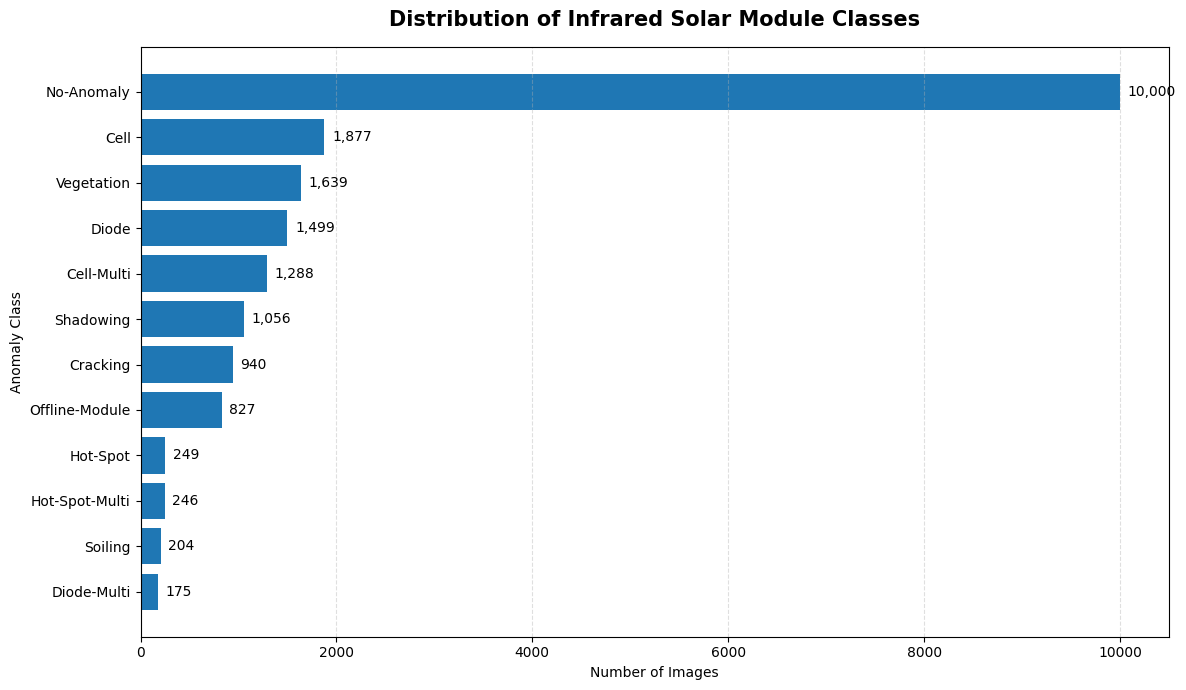

Figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\01_class_distribution.png


In [9]:

plot_data = class_summary.sort_values(
    "number_of_images",
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    plot_data["anomaly_class"],
    plot_data["number_of_images"]
)

ax.set_title(
    "Distribution of Infrared Solar Module Classes",
    fontsize=15,
    pad=15
)
ax.set_xlabel("Number of Images")
ax.set_ylabel("Anomaly Class")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 80,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=10
    )

ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

figure_path = FIGURES_DIR / "01_class_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path.resolve())

## Observation 1 — Strong Class Imbalance

The class distribution reveals a strongly imbalanced multi-class classification problem.

The `No-Anomaly` category contains a very large portion of the images, while several anomaly classes, such as `Diode-Multi`, `Soiling`, `Hot-Spot` and `Hot-Spot-Multi`, contain far fewer examples.

This imbalance has direct consequences for the modeling stage:

- overall accuracy alone will not be sufficient for evaluating the models;
- a model could obtain a high accuracy while performing poorly on rare anomaly categories;
- macro-averaged F1-score will be reported because it gives equal importance to every class;
- per-class recall will be analyzed because missing rare anomalies may be important in a maintenance context;
- class weighting will be tested in one of the multi-class experiments.

This distribution also motivates the hierarchical SolarMedic AI workflow: detecting whether a module is anomalous is operationally different from diagnosing the exact anomaly subtype.

In [10]:
display_table = class_summary[
    ["anomaly_class", "number_of_images", "percentage", "description"]
].copy()

display_table.columns = [
    "Anomaly Class",
    "Number of Images",
    "Percentage (%)",
    "Technical Meaning"
]

display_table

,Anomaly Class,Number of Images,Percentage (%),Technical Meaning
0,No-Anomaly,10000,50.00,Nominal photovoltaic module
1,Cell,1877,9.38,Hot spot occurring in a single cell
2,Vegetation,1639,8.20,Module affected by vegetation
3,Diode,1499,7.50,Activated bypass diode
4,Cell-Multi,1288,6.44,Hot spots occurring in multiple cells
5,Shadowing,1056,5.28,Sunlight blocked by nearby objects or rows
6,Cracking,940,4.70,Thermal anomaly associated with cracking
7,Offline-Module,827,4.14,Entire module appears heated or offline
8,Hot-Spot,249,1.24,Hot spot on a thin-film module
9,Hot-Spot-Multi,246,1.23,Multiple hot spots on a thin-film module


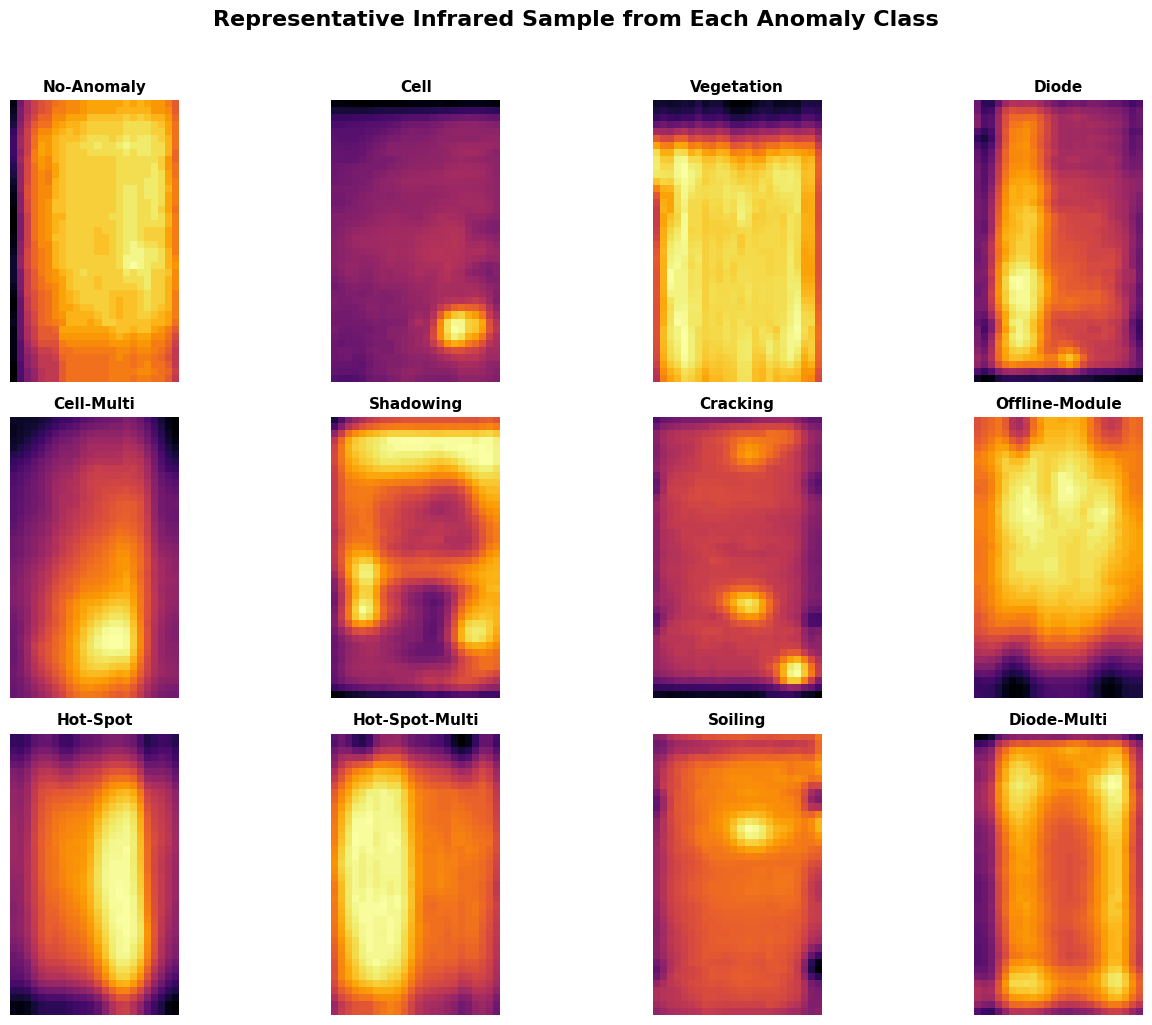

Figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\02_representative_class_gallery.png


In [11]:
ordered_classes = class_summary["anomaly_class"].tolist()

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, class_name in zip(axes.flatten(), ordered_classes):
    sample_row = (
        df[df["anomaly_class"] == class_name]
        .sample(1, random_state=SEED)
        .iloc[0]
    )

    with Image.open(sample_row["filepath"]) as image:
        ax.imshow(image, cmap="inferno")

    ax.set_title(class_name, fontsize=11)
    ax.axis("off")

plt.suptitle(
    "Representative Infrared Sample from Each Anomaly Class",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

figure_path = FIGURES_DIR / "02_representative_class_gallery.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path.resolve())

## Visualization Note — Infrared Representation

The original dataset images are single-channel grayscale infrared samples. For visualization purposes, the `inferno` color map is applied in the notebook because it makes relative intensity patterns easier to inspect.

The displayed colors should not be interpreted as calibrated temperatures in degrees Celsius. They only represent relative pixel intensity values available in the images.

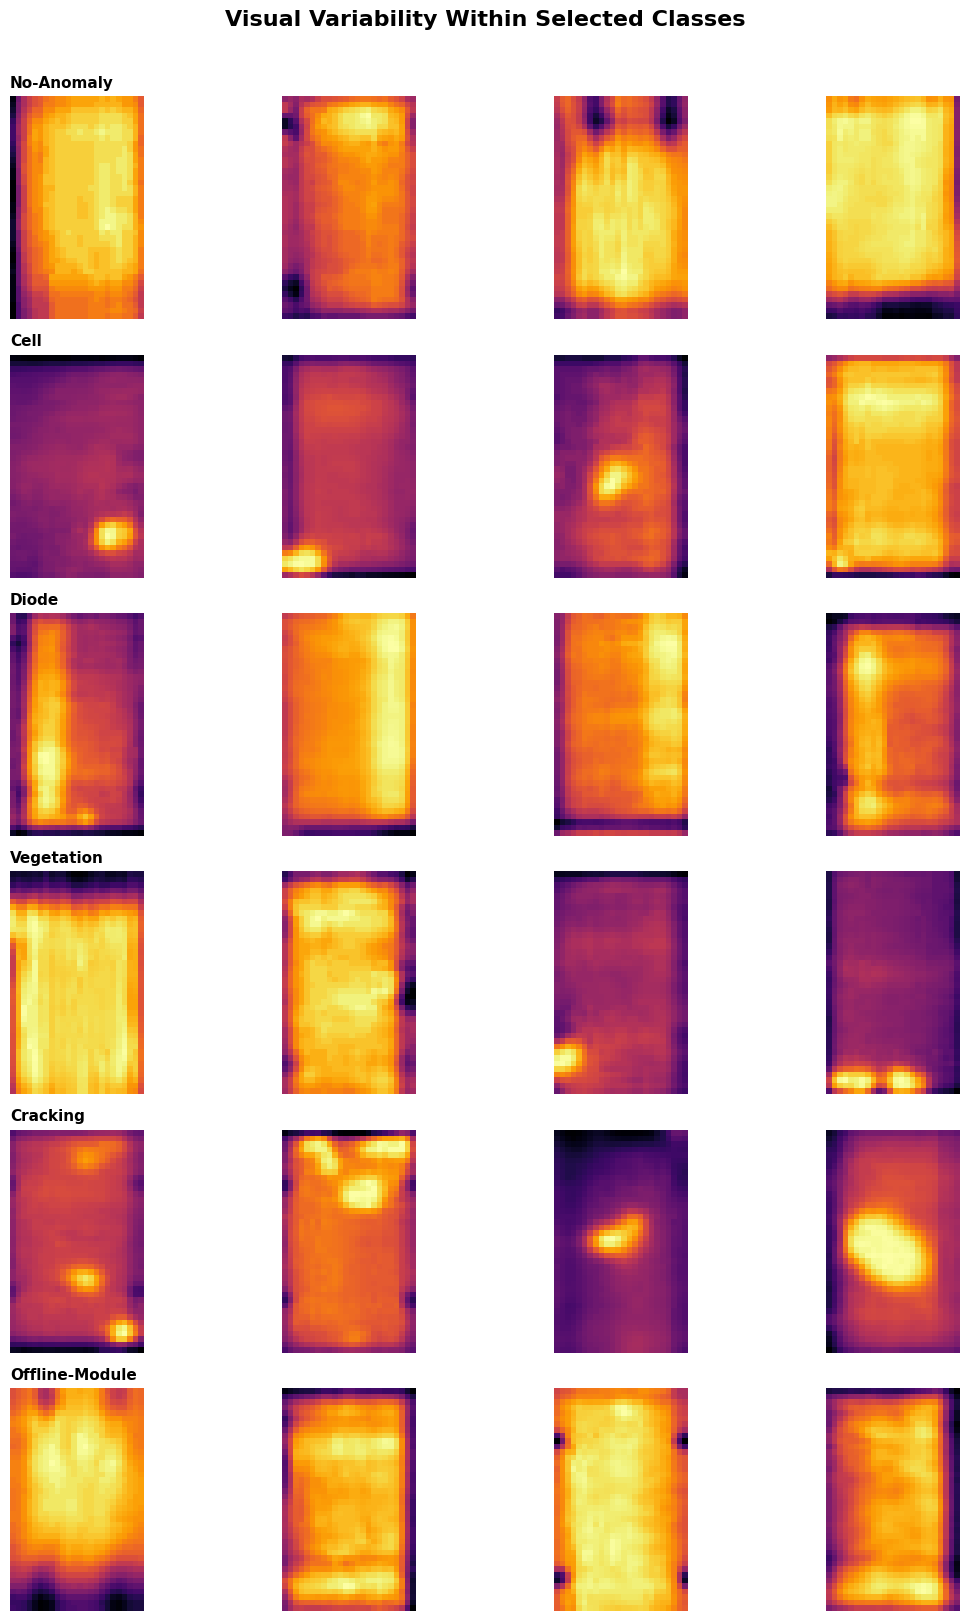

Figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\03_within_class_visual_variability.png


In [12]:
selected_classes = [
    "No-Anomaly",
    "Cell",
    "Diode",
    "Vegetation",
    "Cracking",
    "Offline-Module"
]

fig, axes = plt.subplots(
    len(selected_classes),
    4,
    figsize=(12, 16)
)

for row_index, class_name in enumerate(selected_classes):
    class_samples = (
        df[df["anomaly_class"] == class_name]
        .sample(4, random_state=SEED)
        .reset_index(drop=True)
    )

    for column_index in range(4):
        sample_row = class_samples.iloc[column_index]

        with Image.open(sample_row["filepath"]) as image:
            axes[row_index, column_index].imshow(image, cmap="inferno")

        axes[row_index, column_index].axis("off")

        if column_index == 0:
            axes[row_index, column_index].set_title(
                class_name,
                fontsize=11,
                fontweight="bold",
                loc="left"
            )

plt.suptitle(
    "Visual Variability Within Selected Classes",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

figure_path = FIGURES_DIR / "03_within_class_visual_variability.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path.resolve())

In [13]:
intensity_summary = (
    df.groupby("anomaly_class")["pixel_mean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

intensity_summary.columns = [
    "Number of Images",
    "Mean Intensity",
    "Median Intensity",
    "Standard Deviation",
    "Minimum",
    "Maximum"
]

intensity_summary

,Number of Images,Mean Intensity,Median Intensity,Standard Deviation,Minimum,Maximum
anomaly_class,,,,,,
Hot-Spot-Multi,246,183.65,186.02,24.74,106.65,236.29
Diode-Multi,175,177.30,182.29,25.97,97.36,244.42
Offline-Module,827,173.20,176.90,30.41,74.19,239.19
Soiling,204,170.27,173.23,26.67,92.98,222.49
Vegetation,1639,168.86,171.43,22.53,51.00,230.31
Diode,1499,168.51,174.02,26.07,63.06,244.08
Cell-Multi,1288,167.76,171.18,25.99,35.96,230.29
Cracking,940,166.91,173.07,31.59,52.53,230.74
Hot-Spot,249,164.65,166.00,24.93,55.91,236.74


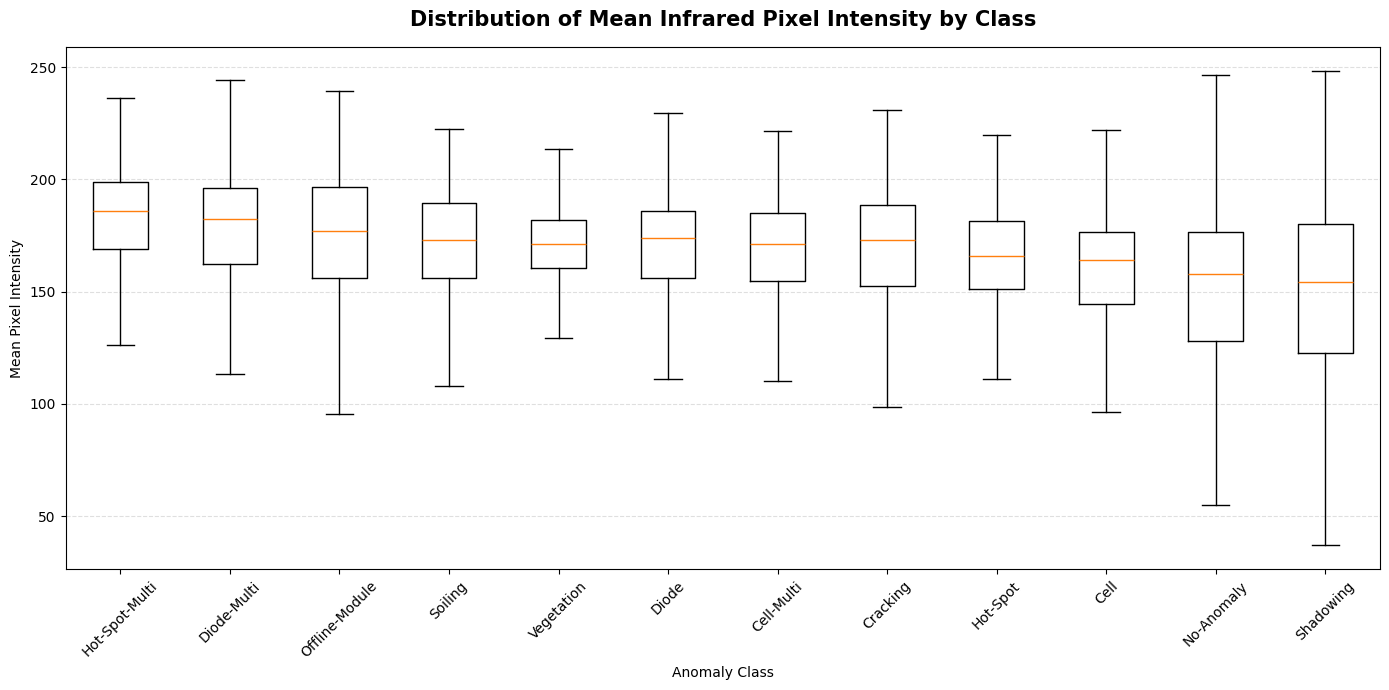

Figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\04_pixel_intensity_by_class.png


In [14]:
class_order_by_intensity = intensity_summary.index.tolist()

boxplot_values = [
    df.loc[df["anomaly_class"] == class_name, "pixel_mean"].values
    for class_name in class_order_by_intensity
]

fig, ax = plt.subplots(figsize=(14, 7))

ax.boxplot(
    boxplot_values,
    tick_labels=class_order_by_intensity,
    showfliers=False
)

ax.set_title(
    "Distribution of Mean Infrared Pixel Intensity by Class",
    fontsize=15,
    pad=15
)
ax.set_xlabel("Anomaly Class")
ax.set_ylabel("Mean Pixel Intensity")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

figure_path = FIGURES_DIR / "04_pixel_intensity_by_class.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path.resolve())

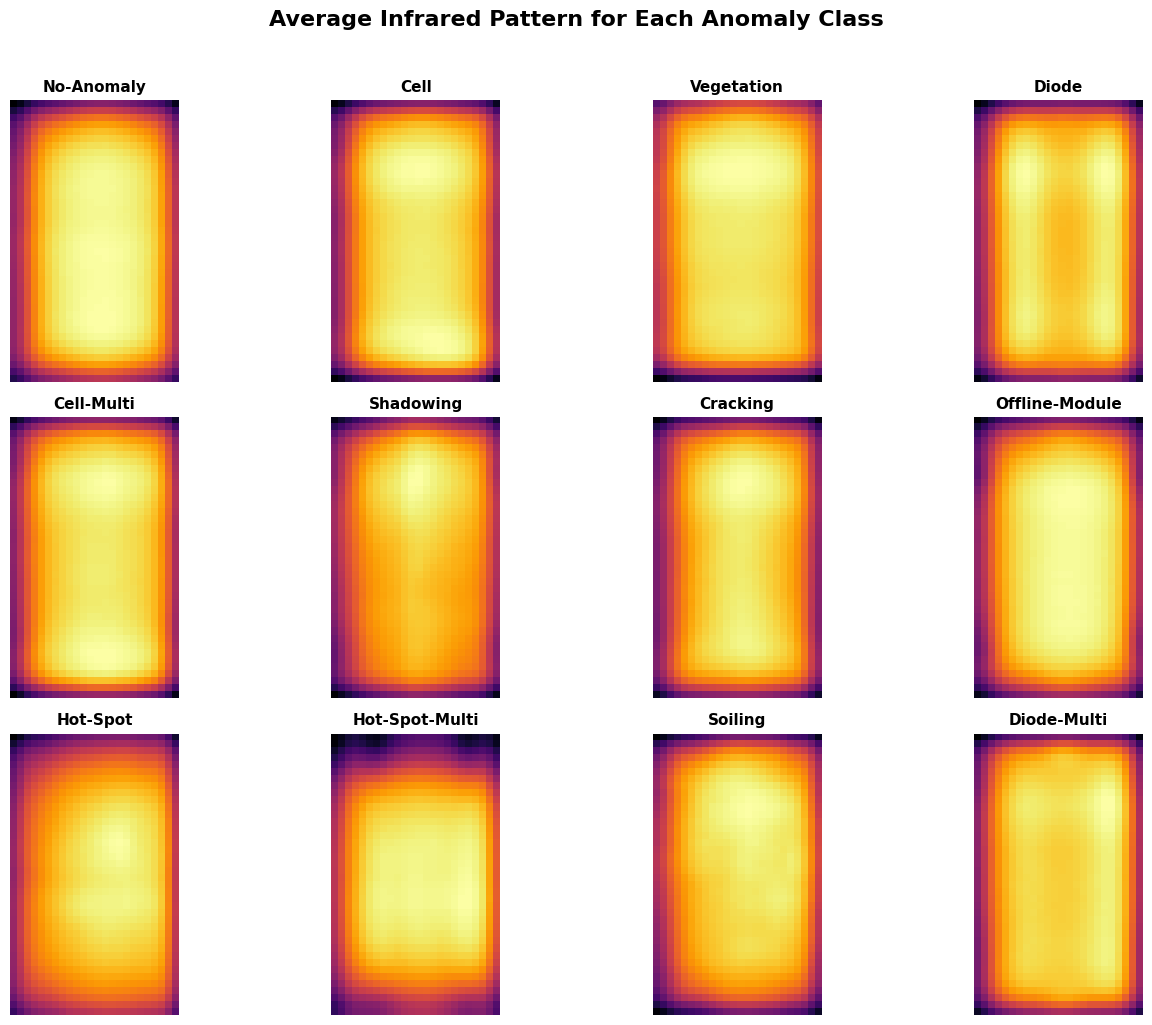

Figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\05_average_thermal_patterns.png


In [15]:
def compute_average_image(class_name):
    """
    Computes the average grayscale image for all samples in one anomaly class.
    """
    class_paths = df.loc[
        df["anomaly_class"] == class_name,
        "filepath"
    ]

    image_arrays = []

    for image_path in class_paths:
        with Image.open(image_path) as image:
            image_arrays.append(np.array(image, dtype=np.float32))

    return np.mean(image_arrays, axis=0)


fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, class_name in zip(axes.flatten(), ordered_classes):
    average_image = compute_average_image(class_name)

    ax.imshow(average_image, cmap="inferno")
    ax.set_title(class_name, fontsize=11)
    ax.axis("off")

plt.suptitle(
    "Average Infrared Pattern for Each Anomaly Class",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

figure_path = FIGURES_DIR / "05_average_thermal_patterns.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path.resolve())

# 6. Exploratory Data Analysis Conclusions

The exploratory analysis leads to several important conclusions for the modeling stage:

1. The dataset contains meaningful infrared patterns for photovoltaic module analysis, but the images have a very low spatial resolution of only 24 × 40 pixels.
2. The twelve-class diagnosis problem is strongly imbalanced, with `No-Anomaly` representing a very large proportion of the dataset and several rare anomaly categories containing far fewer examples.
3. Representative image galleries suggest that some classes may be visually distinguishable, while other classes may share similar thermal patterns.
4. Mean pixel intensity provides useful descriptive information, but it is not sufficient by itself for technical diagnosis because anomaly position and spatial structure are also relevant.
5. Average thermal images may reveal recurring class-specific patterns, while also indicating possible sources of confusion between similar anomaly categories.

## Consequences for the Experiments

Based on these findings, the following experimental decisions are justified:

- a binary triage task will first be studied: `Normal` versus `Anomaly Detected`;
- a multi-class diagnosis task will then investigate the prediction of specific anomaly types;
- overall accuracy will be supplemented with macro F1-score and per-class recall;
- class weighting will be tested to reduce the effect of class imbalance;
- error analysis will focus especially on rare and visually similar anomaly classes.

# 6. Exploratory Data Analysis Conclusions

The exploratory analysis reveals several important characteristics of the Infrared Solar Modules dataset.

## Main Findings

1. The dataset contains a highly imbalanced twelve-class diagnosis problem. The `No-Anomaly` class contains 10,000 images, representing 50% of the entire dataset, while the rarest anomaly class, `Diode-Multi`, contains only 175 images.

2. The imbalance ratio between the largest and smallest classes is approximately 57:1. Consequently, a model evaluated only through overall accuracy could appear successful while failing to recognize rare anomaly types.

3. Representative thermal images indicate that several classes contain visually meaningful patterns:
   - `Cell` examples may contain localized bright regions;
   - `Diode` examples may contain elongated or band-like thermal patterns;
   - `Offline-Module` examples may exhibit broader heated regions;
   - `Vegetation`, `Cracking` and other classes may present less uniform patterns.

4. The within-class gallery shows that thermal appearances can vary considerably even within the same anomaly category. Therefore, classification cannot rely only on one simple property such as global brightness.

5. The very small image resolution of 24 × 40 pixels represents an important limitation. The objective of this project is module-level anomaly diagnosis, not exact physical localization of microscopic defects.

## Consequences for Experimental Design

Based on these findings, the following decisions are justified:

- a binary triage task will first distinguish `Normal` modules from modules with `Anomaly Detected`;
- a multi-class model will then attempt to predict the specific anomaly category;
- macro F1-score and per-class recall will be reported in addition to accuracy;
- class weighting will be evaluated during multi-class training;
- visual error analysis will focus especially on rare and visually similar anomaly classes;
- a final hierarchical SolarMedic AI workflow will combine diagnosis with a demonstrative maintenance priority.

# 7. SolarMedic AI Operational Labels

The original dataset provides twelve technical anomaly classes. For the proposed SolarMedic AI prototype, two additional operational outputs are derived.

## Binary Triage Task

The first deep learning task answers a practical inspection question:

> Should this photovoltaic module be considered normal or should it be inspected further?

The two binary classes are:

- `Normal`
- `Anomaly Detected`

## Demonstrative Maintenance Priority

A maintenance-priority label is also derived from the original anomaly category:

| Priority | Original Classes | Interpretation |
|---|---|---|
| `Low` | No-Anomaly | No anomaly detected |
| `Moderate` | Shadowing, Vegetation, Soiling | Possible external obstruction or cleaning need |
| `High` | Cell, Hot-Spot, Cracking, Diode | Localized or component-level thermal issue |
| `Critical` | Cell-Multi, Hot-Spot-Multi, Diode-Multi, Offline-Module | Multiple or severe anomaly pattern |

This priority system is a demonstrative educational component of the prototype. It is not an official photovoltaic maintenance standard.

In [16]:

priority_mapping = {
    "No-Anomaly": "Low",

    "Shadowing": "Moderate",
    "Vegetation": "Moderate",
    "Soiling": "Moderate",

    "Cell": "High",
    "Hot-Spot": "High",
    "Cracking": "High",
    "Diode": "High",

    "Cell-Multi": "Critical",
    "Hot-Spot-Multi": "Critical",
    "Diode-Multi": "Critical",
    "Offline-Module": "Critical"
}

df["triage_label"] = np.where(
    df["anomaly_class"] == "No-Anomaly",
    "Normal",
    "Anomaly Detected"
)

df["is_anomaly"] = (
    df["anomaly_class"] != "No-Anomaly"
).astype(int)

df["maintenance_priority"] = df["anomaly_class"].map(priority_mapping)

assert df["maintenance_priority"].notna().all()
assert set(df["is_anomaly"].unique()) == {0, 1}

operational_mapping = (
    df[
        [
            "anomaly_class",
            "triage_label",
            "maintenance_priority"
        ]
    ]
    .drop_duplicates()
    .sort_values(["maintenance_priority", "anomaly_class"])
    .reset_index(drop=True)
)

print("Operational labels created successfully.")
operational_mapping

Operational labels created successfully.


,anomaly_class,triage_label,maintenance_priority
0,Cell-Multi,Anomaly Detected,Critical
1,Diode-Multi,Anomaly Detected,Critical
2,Hot-Spot-Multi,Anomaly Detected,Critical
3,Offline-Module,Anomaly Detected,Critical
4,Cell,Anomaly Detected,High
5,Cracking,Anomaly Detected,High
6,Diode,Anomaly Detected,High
7,Hot-Spot,Anomaly Detected,High
8,No-Anomaly,Normal,Low
9,Shadowing,Anomaly Detected,Moderate


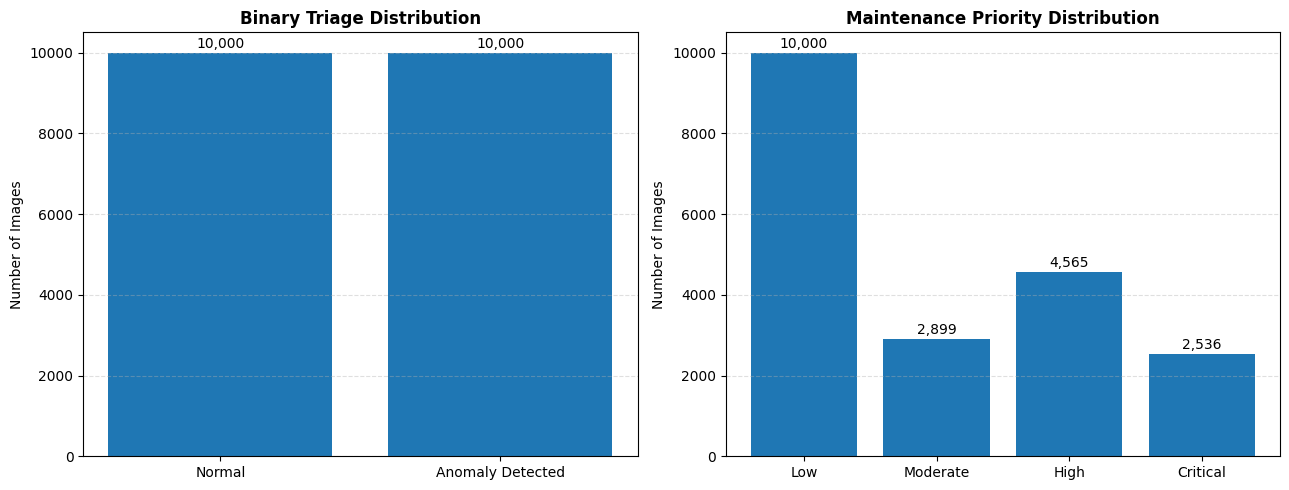

Binary triage distribution:
triage_label
Normal              10000
Anomaly Detected    10000
Name: count, dtype: int64

Maintenance priority distribution:
maintenance_priority
Low         10000
Moderate     2899
High         4565
Critical     2536
Name: count, dtype: int64

Figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\06_operational_label_distributions.png


In [17]:

triage_distribution = (
    df["triage_label"]
    .value_counts()
    .reindex(["Normal", "Anomaly Detected"])
)

priority_order = ["Low", "Moderate", "High", "Critical"]

priority_distribution = (
    df["maintenance_priority"]
    .value_counts()
    .reindex(priority_order)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

triage_bars = axes[0].bar(
    triage_distribution.index,
    triage_distribution.values
)

axes[0].set_title("Binary Triage Distribution")
axes[0].set_ylabel("Number of Images")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

for bar in triage_bars:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height + 120,
        f"{int(height):,}",
        ha="center"
    )

priority_bars = axes[1].bar(
    priority_distribution.index,
    priority_distribution.values
)

axes[1].set_title("Maintenance Priority Distribution")
axes[1].set_ylabel("Number of Images")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

for bar in priority_bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 120,
        f"{int(height):,}",
        ha="center"
    )

plt.tight_layout()

figure_path = FIGURES_DIR / "06_operational_label_distributions.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Binary triage distribution:")
print(triage_distribution)

print("\nMaintenance priority distribution:")
print(priority_distribution)

print("\nFigure saved to:")
print(figure_path.resolve())

## Observation — Why the Hierarchical Workflow Is Appropriate

The original twelve-class diagnosis problem is strongly imbalanced. However, after deriving the binary triage target, the dataset contains an equal number of normal and anomalous modules.

This supports the proposed SolarMedic AI workflow:

1. A first model will classify modules as `Normal` or `Anomaly Detected`.
2. A second, more challenging model will diagnose the specific anomaly category.
3. The final application layer will convert the predicted anomaly into a demonstrative maintenance priority.

The balanced binary task provides a suitable starting point for the first deep learning experiment.

# 8. Train, Validation and Test Split

The dataset is divided into three subsets:

- **70% training set** — used to learn the model parameters;
- **15% validation set** — used to monitor training performance and select the best model;
- **15% test set** — used only for final evaluation.

The split is stratified according to the original twelve-class anomaly label. This ensures that both frequent and rare anomaly classes remain represented in all subsets.

A limitation of this project is that the available metadata does not include photovoltaic-site identifiers. Therefore, the evaluation is based on an image-level stratified split. A stronger industrial evaluation would test the model on images collected from entirely unseen solar installations.

In [18]:
train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["anomaly_class"]
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["anomaly_class"]
)

train_df = train_df.copy()
validation_df = validation_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
validation_df["split"] = "validation"
test_df["split"] = "test"

full_manifest = pd.concat(
    [train_df, validation_df, test_df],
    ignore_index=True
)

print("DATA SPLIT REPORT")
print("-" * 35)
print(f"Training images:   {len(train_df):,}")
print(f"Validation images: {len(validation_df):,}")
print(f"Test images:       {len(test_df):,}")
print(f"Total images:      {len(full_manifest):,}")

assert len(train_df) == 14000
assert len(validation_df) == 3000
assert len(test_df) == 3000
assert len(full_manifest) == 20000
assert full_manifest["image_id"].is_unique

print("\nStratified split completed successfully.")

DATA SPLIT REPORT
-----------------------------------
Training images:   14,000
Validation images: 3,000
Test images:       3,000
Total images:      20,000

Stratified split completed successfully.


In [19]:
split_distribution = pd.crosstab(
    full_manifest["anomaly_class"],
    full_manifest["split"]
)

split_distribution["total"] = split_distribution.sum(axis=1)

split_distribution = split_distribution.sort_values(
    "total",
    ascending=False
)

split_distribution

split,test,train,validation,total
anomaly_class,,,,
No-Anomaly,1500,7000,1500,10000
Cell,281,1314,282,1877
Vegetation,246,1147,246,1639
Diode,225,1049,225,1499
Cell-Multi,193,902,193,1288
Shadowing,159,739,158,1056
Cracking,141,658,141,940
Offline-Module,124,579,124,827
Hot-Spot,37,174,38,249


In [20]:
columns_to_save = [
    "image_id",
    "filename",
    "filepath",
    "anomaly_class",
    "triage_label",
    "is_anomaly",
    "maintenance_priority",
    "width",
    "height",
    "image_mode",
    "pixel_mean",
    "pixel_std",
    "split"
]

manifest_to_save = full_manifest[columns_to_save].copy()

# Store relative paths so that the project remains portable.
manifest_to_save["filepath"] = manifest_to_save["filepath"].apply(
    lambda path: str(Path(path).relative_to(PROJECT_ROOT))
)

manifest_path = DATA_PROCESSED_DIR / "solar_modules_manifest.csv"

manifest_to_save.to_csv(manifest_path, index=False)

print("Processed dataset manifest saved successfully.")
print("Location:", manifest_path.resolve())
print("Shape:", manifest_to_save.shape)

print("\nSplit counts:")
print(manifest_to_save["split"].value_counts())

manifest_to_save.head()

Processed dataset manifest saved successfully.
Location: C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\data\processed\solar_modules_manifest.csv
Shape: (20000, 13)

Split counts:
split
train         14000
validation     3000
test           3000
Name: count, dtype: int64


,image_id,filename,filepath,anomaly_class,triage_label,is_anomaly,maintenance_priority,width,height,image_mode,pixel_mean,pixel_std,split
0,11336,11336.jpg,data\raw\archive\2020-02-14_InfraredSolarModul...,No-Anomaly,Normal,0,Low,24,40,L,163.183333,17.895988,train
1,12983,12983.jpg,data\raw\archive\2020-02-14_InfraredSolarModul...,No-Anomaly,Normal,0,Low,24,40,L,109.663542,16.375487,train
2,11259,11259.jpg,data\raw\archive\2020-02-14_InfraredSolarModul...,No-Anomaly,Normal,0,Low,24,40,L,95.910417,18.303127,train
3,13083,13083.jpg,data\raw\archive\2020-02-14_InfraredSolarModul...,No-Anomaly,Normal,0,Low,24,40,L,139.425000,23.181454,train
4,5806,5806.jpg,data\raw\archive\2020-02-14_InfraredSolarModul...,Cell,Anomaly Detected,1,High,24,40,L,180.395833,10.207615,train


# 9. Data Preparation Conclusion

The dataset is now ready for deep learning experiments:

- the original infrared images remain unchanged;
- the dataset contains 20,000 validated thermal module images;
- exploratory analysis identified a challenging and imbalanced twelve-class diagnosis task;
- a balanced binary triage task was derived for the first model;
- a demonstrative maintenance-priority mapping was defined for the final prototype;
- stratified training, validation and test subsets were created;
- a clean processed manifest was saved for model development.

The next stage begins the deep learning experiments with a binary CNN baseline for `Normal` versus `Anomaly Detected` classification.

# 10. Experimental Design

The modeling stage is organized as a sequence of increasingly challenging experiments.

## Experiment 1 — Binary CNN Baseline

The first experiment addresses the balanced binary triage task:

- `Normal`
- `Anomaly Detected`

A custom convolutional neural network will be trained directly on the infrared module images. This model provides a clear baseline for the operational question of whether a photovoltaic module requires further inspection.

## Experiment 2 — Improved Binary CNN

A second binary model will investigate whether regularization and data augmentation improve generalization and reduce prediction errors.

## Experiment 3 — Multi-Class Diagnosis Model

The final diagnostic experiment will attempt to distinguish between the original twelve anomaly classes. This task is considerably more difficult because the classes are visually similar and strongly imbalanced.

## Final SolarMedic Workflow

The best-performing models will be integrated into a prototype inspection workflow:

1. binary triage prediction;
2. anomaly diagnosis;
3. maintenance-priority assignment;
4. visual inspection report.

## Evaluation Metrics

For the binary model, the following metrics will be reported:

- accuracy;
- precision;
- recall;
- F1-score;
- ROC-AUC;
- confusion matrix.

Recall is especially relevant because a false negative represents an anomalous module incorrectly classified as normal.

# 11. Experiment 1 — Binary CNN Baseline

## Objective

The objective of this experiment is to train a convolutional neural network that predicts whether an infrared photovoltaic-module image represents:

- a normal module;
- a module with a detected anomaly.

This is a suitable first deep learning experiment because the binary target is perfectly balanced, with 10,000 normal images and 10,000 anomalous images.

## Baseline Strategy

The baseline model intentionally uses a compact CNN architecture trained from scratch. Since the images are very small grayscale samples, a lightweight model is appropriate for establishing an initial performance reference before testing more advanced improvements.

No artificial image augmentation is used in this first experiment. This ensures that the baseline performance reflects learning from the original training samples only.

In [21]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print("Modeling and evaluation libraries imported successfully.")

Modeling and evaluation libraries imported successfully.


In [22]:
IMG_HEIGHT = 40
IMG_WIDTH = 24
CHANNELS = 1

INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)

BATCH_SIZE = 128
MAX_EPOCHS = 25

BINARY_MODEL_PATH = MODELS_DIR / "binary_cnn_baseline.keras"

print("BINARY CNN BASELINE CONFIGURATION")
print("-" * 40)
print("Input shape:", INPUT_SHAPE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Model save path:", BINARY_MODEL_PATH.resolve())

BINARY CNN BASELINE CONFIGURATION
----------------------------------------
Input shape: (40, 24, 1)
Batch size: 128
Maximum epochs: 25
Model save path: C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\models\binary_cnn_baseline.keras


In [23]:
binary_split_distribution = pd.crosstab(
    full_manifest["split"],
    full_manifest["triage_label"]
)

binary_split_distribution = binary_split_distribution[
    ["Normal", "Anomaly Detected"]
]

binary_split_distribution

triage_label,Normal,Anomaly Detected
split,,
test,1500,1500
train,7000,7000
validation,1500,1500


In [24]:
AUTOTUNE = tf.data.AUTOTUNE

def load_binary_image(image_path, label):
    """
    Reads one infrared JPG image, converts it to a normalized
    single-channel tensor, and returns it with the binary target.
    """
    image = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image, channels=1)
    image = tf.image.convert_image_dtype(image, tf.float32)

    image.set_shape([IMG_HEIGHT, IMG_WIDTH, CHANNELS])

    label = tf.cast(label, tf.float32)

    return image, label


def create_binary_dataset(dataframe, training=False):
    """
    Creates an efficient TensorFlow dataset from a DataFrame.
    """
    image_paths = dataframe["filepath"].astype(str).values
    labels = dataframe["is_anomaly"].astype("float32").values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    dataset = dataset.map(
        load_binary_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.cache()

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


binary_train_ds = create_binary_dataset(train_df, training=True)
binary_validation_ds = create_binary_dataset(validation_df, training=False)
binary_test_ds = create_binary_dataset(test_df, training=False)

print("TensorFlow binary datasets created successfully.")

TensorFlow binary datasets created successfully.


In [25]:
sample_images, sample_labels = next(iter(binary_train_ds))

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Minimum normalized pixel value:", float(tf.reduce_min(sample_images)))
print("Maximum normalized pixel value:", float(tf.reduce_max(sample_images)))
print("First 10 binary labels:", sample_labels[:10].numpy())

Image batch shape: (128, 40, 24, 1)
Label batch shape: (128,)
Minimum normalized pixel value: 0.0
Maximum normalized pixel value: 1.0
First 10 binary labels: [1. 1. 1. 1. 1. 1. 1. 0. 0. 0.]


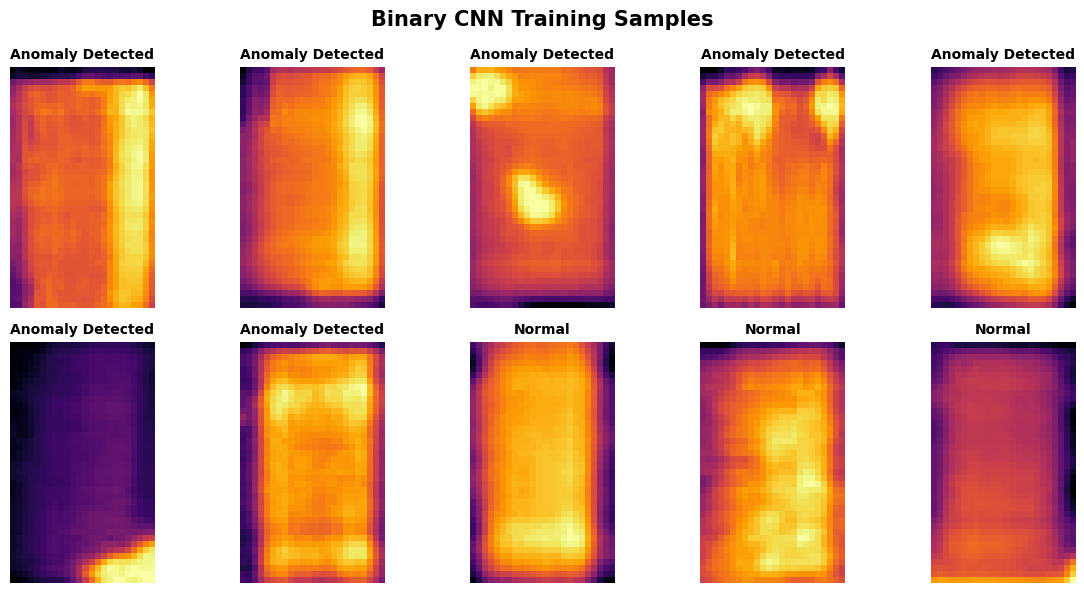

Figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\07_binary_training_samples.png


In [26]:

label_names = {
    0: "Normal",
    1: "Anomaly Detected"
}

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for index, ax in enumerate(axes.flatten()):
    image = sample_images[index].numpy().squeeze()
    label = int(sample_labels[index].numpy())

    ax.imshow(image, cmap="inferno")
    ax.set_title(label_names[label], fontsize=10)
    ax.axis("off")

plt.suptitle(
    "Binary CNN Training Samples",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

figure_path = FIGURES_DIR / "07_binary_training_samples.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path.resolve())

In [27]:
tf.keras.backend.clear_session()

binary_cnn_baseline = Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(
        filters=16,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    GlobalAveragePooling2D(),

    Dense(32, activation="relu"),
    Dropout(0.30),

    Dense(1, activation="sigmoid")
])

binary_cnn_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

binary_cnn_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 24, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 12, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 6, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,409 (99.25 KB)

 Trainable params: 25,409 (99.25 KB)

 Non-trainable params: 0 (0.00 B)

## Baseline Model Architecture Rationale

The baseline model uses a compact convolutional architecture trained from scratch.

This design is appropriate for the first experiment because:

- the input images are extremely small grayscale samples;
- convolutional layers can learn spatial thermal patterns, such as local bright regions or broader heated areas;
- the model is intentionally lightweight, providing a clear baseline before introducing augmentation or more advanced architectures;
- dropout is included to reduce overfitting risk;
- the sigmoid output is suitable for the binary triage task.

The objective of this experiment is not to create the final model immediately, but to establish a reliable initial performance reference.

In [28]:
binary_callbacks = [
    ModelCheckpoint(
        filepath=BINARY_MODEL_PATH,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Training callbacks prepared successfully.")

Training callbacks prepared successfully.


In [29]:
binary_history = binary_cnn_baseline.fit(
    binary_train_ds,
    validation_data=binary_validation_ds,
    epochs=MAX_EPOCHS,
    callbacks=binary_callbacks,
    verbose=1
)

Epoch 1/25
105/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5194 - auc: 0.5544 - loss: 0.6907 - precision: 0.5101 - recall: 0.8362
Epoch 1: val_auc improved from None to 0.64809, saving model to c:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\models\binary_cnn_baseline.keras

Epoch 1: finished saving model to c:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\models\binary_cnn_baseline.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5451 - auc: 0.5818 - loss: 0.6858 - precision: 0.5299 - recall: 0.8007 - val_accuracy: 0.5863 - val_auc: 0.6481 - val_loss: 0.6761 - val_precision: 0.5541 - val_recall: 0.8840 - learning_rate: 0.0010
Epoch 2/25
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5997 - auc: 0.6332 - loss: 0.6691 - precision: 0.5885 - recall: 0.6527
Epoch 2: val_auc improved from 0.64809 to 0.68230, sa

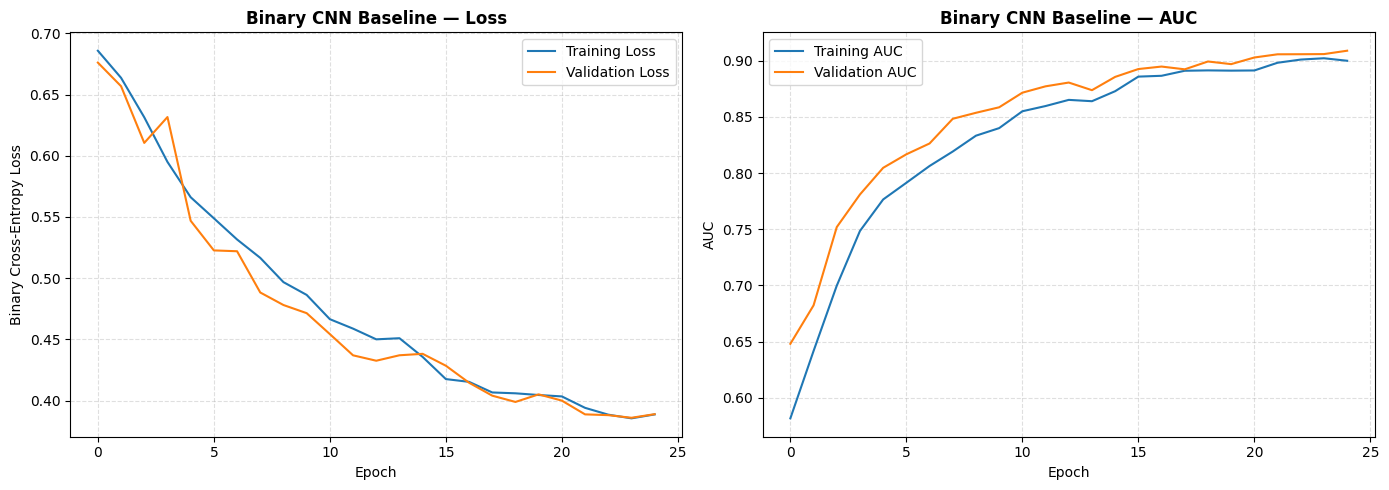

Training figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\08_binary_baseline_training_history.png

Training history saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\metrics\binary_baseline_training_history.csv


In [30]:

history_df = pd.DataFrame(binary_history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["loss"], label="Training Loss")
axes[0].plot(history_df["val_loss"], label="Validation Loss")
axes[0].set_title("Binary CNN Baseline — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.4)

axes[1].plot(history_df["auc"], label="Training AUC")
axes[1].plot(history_df["val_auc"], label="Validation AUC")
axes[1].set_title("Binary CNN Baseline — AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.4)

plt.tight_layout()

figure_path = FIGURES_DIR / "08_binary_baseline_training_history.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

history_path = METRICS_DIR / "binary_baseline_training_history.csv"
history_df.to_csv(history_path, index=False)

print("Training figure saved to:")
print(figure_path.resolve())

print("\nTraining history saved to:")
print(history_path.resolve())

In [31]:

best_binary_baseline = tf.keras.models.load_model(BINARY_MODEL_PATH)

test_results = best_binary_baseline.evaluate(
    binary_test_ds,
    return_dict=True,
    verbose=0
)

print("BINARY CNN BASELINE — TEST RESULTS")
print("-" * 45)

for metric_name, metric_value in test_results.items():
    print(f"{metric_name:<12}: {metric_value:.4f}")

BINARY CNN BASELINE — TEST RESULTS
---------------------------------------------
accuracy    : 0.8220
auc         : 0.9076
loss        : 0.3806
precision   : 0.9032
recall      : 0.7213


In [32]:

y_true_binary = test_df["is_anomaly"].values

y_probability_binary = (
    best_binary_baseline.predict(binary_test_ds, verbose=0)
    .ravel()
)

y_pred_binary = (
    y_probability_binary >= 0.50
).astype(int)

binary_f1 = f1_score(
    y_true_binary,
    y_pred_binary
)

binary_roc_auc = roc_auc_score(
    y_true_binary,
    y_probability_binary
)

binary_report = classification_report(
    y_true_binary,
    y_pred_binary,
    target_names=["Normal", "Anomaly Detected"],
    output_dict=True
)

binary_report_df = pd.DataFrame(binary_report).transpose()

print("Binary Test F1-score:", round(binary_f1, 4))
print("Binary Test ROC-AUC:", round(binary_roc_auc, 4))

binary_report_df

Binary Test F1-score: 0.8021
Binary Test ROC-AUC: 0.9075


,precision,recall,f1-score,support
Normal,0.768036,0.922667,0.838280,1500.000
Anomaly Detected,0.903172,0.721333,0.802076,1500.000
accuracy,0.822000,0.822000,0.822000,0.822
macro avg,0.835604,0.822000,0.820178,3000.000
weighted avg,0.835604,0.822000,0.820178,3000.000


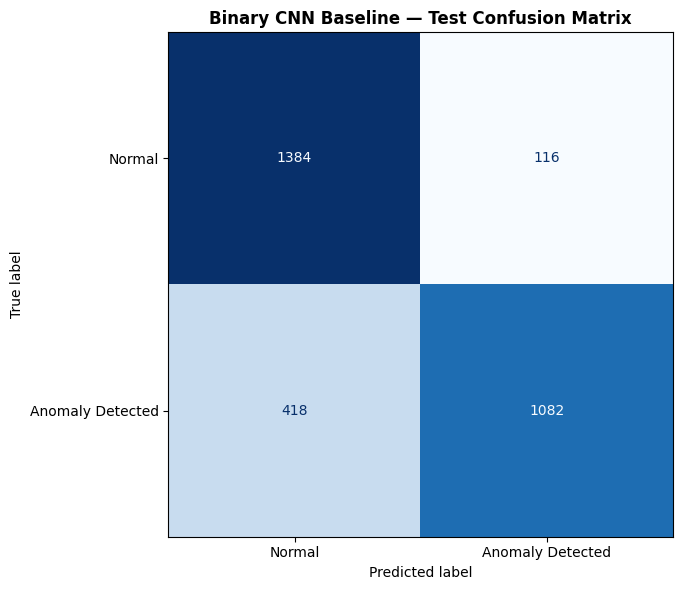

Confusion matrix figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\09_binary_baseline_confusion_matrix.png

Classification report saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\metrics\binary_baseline_classification_report.csv


In [33]:

binary_confusion_matrix = confusion_matrix(
    y_true_binary,
    y_pred_binary
)

fig, ax = plt.subplots(figsize=(7, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix=binary_confusion_matrix,
    display_labels=["Normal", "Anomaly Detected"]
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("Binary CNN Baseline — Test Confusion Matrix")

plt.tight_layout()

figure_path = FIGURES_DIR / "09_binary_baseline_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

report_path = METRICS_DIR / "binary_baseline_classification_report.csv"
binary_report_df.to_csv(report_path)

print("Confusion matrix figure saved to:")
print(figure_path.resolve())

print("\nClassification report saved to:")
print(report_path.resolve())

In [34]:

binary_baseline_summary = pd.DataFrame({
    "Experiment": ["Binary CNN Baseline"],
    "Task": ["Normal vs Anomaly Detected"],
    "Accuracy": [test_results["accuracy"]],
    "Precision": [test_results["precision"]],
    "Recall": [test_results["recall"]],
    "F1_Score": [binary_f1],
    "ROC_AUC": [binary_roc_auc],
    "Model_Path": [str(BINARY_MODEL_PATH)]
})

summary_path = METRICS_DIR / "experiment_summary.csv"

binary_baseline_summary.to_csv(
    summary_path,
    index=False
)

binary_baseline_summary

,Experiment,Task,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Model_Path
0,Binary CNN Baseline,Normal vs Anomaly Detected,0.822,0.903172,0.721333,0.802076,0.90748,c:\Users\Carla Bozintan\OneDrive - Technical U...


## Experiment 1 Results and Quality Analysis

The Binary CNN Baseline achieved an accuracy of **82.20%** and a ROC-AUC of approximately **0.9075** on the unseen test set.

| Metric | Test Result |
|---|---:|
| Accuracy | 0.8220 |
| Precision — Anomaly Detected | 0.9032 |
| Recall — Anomaly Detected | 0.7213 |
| F1-score — Anomaly Detected | 0.8021 |
| ROC-AUC | 0.9075 |

## Interpretation

The baseline model shows strong discrimination ability, as indicated by the ROC-AUC score above 0.90. It is also highly precise when predicting an anomaly: approximately 90% of modules classified as anomalous are truly anomalous.

However, the recall for `Anomaly Detected` is only approximately 72%. This means that the model fails to identify a substantial number of anomalous photovoltaic modules.

Based on the test results:

- 1,082 anomalous modules were detected correctly;
- 418 anomalous modules were incorrectly classified as normal;
- 116 normal modules were incorrectly flagged as anomalous;
- 1,384 normal modules were identified correctly.

## Operational Consequence

For a maintenance-screening application, false negatives are particularly important because an anomalous module classified as normal may not be inspected further.

Therefore, Experiment 2 will focus on improving anomaly recall while maintaining acceptable precision. The improved model will introduce:

- mild image augmentation;
- batch normalization;
- a slightly more regularized CNN architecture;
- threshold selection based only on validation data, using an F2-score criterion that gives additional importance to recall.

## False Negative Analysis

The most operationally sensitive errors are **false negatives**: anomalous modules predicted as normal.

The following analysis investigates which original anomaly classes are most frequently missed by the baseline model and displays representative examples of these errors.

In [35]:

binary_test_predictions = test_df.reset_index(drop=True).copy()

binary_test_predictions["anomaly_probability"] = y_probability_binary
binary_test_predictions["predicted_is_anomaly"] = y_pred_binary
binary_test_predictions["predicted_triage_label"] = np.where(
    binary_test_predictions["predicted_is_anomaly"] == 1,
    "Anomaly Detected",
    "Normal"
)

false_negatives = binary_test_predictions[
    (binary_test_predictions["is_anomaly"] == 1) &
    (binary_test_predictions["predicted_is_anomaly"] == 0)
].copy()

false_negative_distribution = (
    false_negatives["anomaly_class"]
    .value_counts()
    .rename_axis("Missed Anomaly Class")
    .reset_index(name="Number of Missed Images")
)

print("FALSE NEGATIVE ANALYSIS")
print("-" * 40)
print("Total anomalous images in test set:", int(test_df["is_anomaly"].sum()))
print("Anomalies correctly detected:", int(
    ((binary_test_predictions["is_anomaly"] == 1) &
     (binary_test_predictions["predicted_is_anomaly"] == 1)).sum()
))
print("Anomalies incorrectly predicted as normal:", len(false_negatives))

false_negative_distribution

FALSE NEGATIVE ANALYSIS
----------------------------------------
Total anomalous images in test set: 1500
Anomalies correctly detected: 1082
Anomalies incorrectly predicted as normal: 418


,Missed Anomaly Class,Number of Missed Images
0,Offline-Module,89
1,Shadowing,85
2,Cell,76
3,Diode,52
4,Vegetation,40
5,Cell-Multi,28
6,Hot-Spot,22
7,Hot-Spot-Multi,14
8,Soiling,5
9,Diode-Multi,4


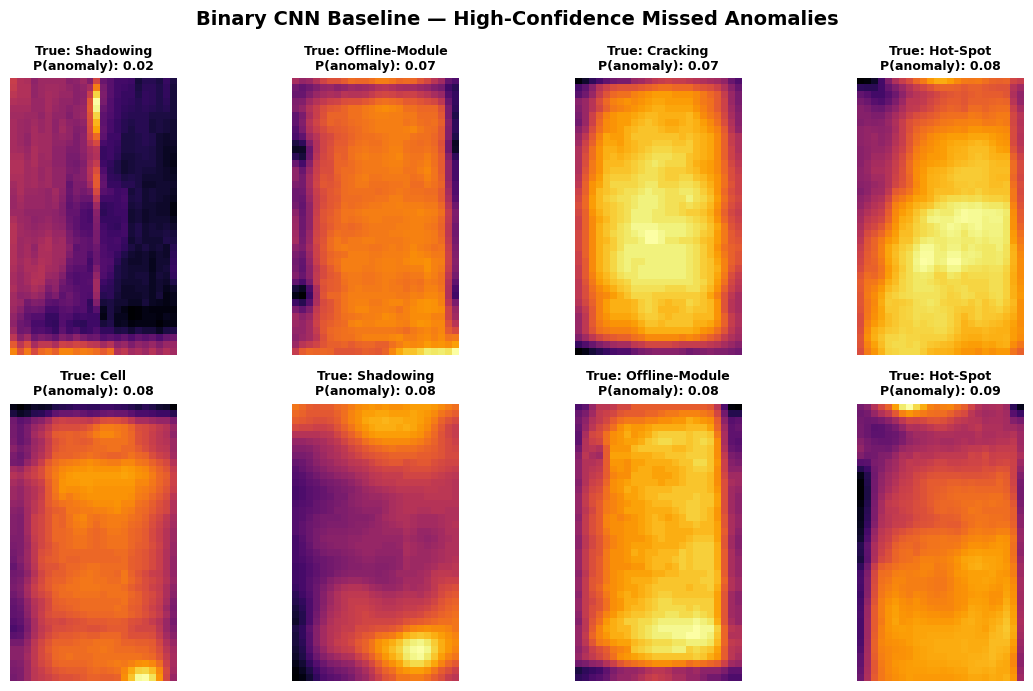

Figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\10_binary_baseline_false_negatives.png


In [36]:

hard_false_negatives = (
    false_negatives
    .sort_values("anomaly_probability", ascending=True)
    .head(8)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 4, figsize=(12, 7))

for index, ax in enumerate(axes.flatten()):
    sample = hard_false_negatives.iloc[index]

    with Image.open(sample["filepath"]) as image:
        ax.imshow(image, cmap="inferno")

    ax.set_title(
        f"True: {sample['anomaly_class']}\n"
        f"P(anomaly): {sample['anomaly_probability']:.2f}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle(
    "Binary CNN Baseline — High-Confidence Missed Anomalies",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

figure_path = FIGURES_DIR / "10_binary_baseline_false_negatives.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path.resolve())

# 12. Experiment 2 — Improved Binary CNN with Augmentation and Recall-Oriented Thresholding

## Motivation

The binary baseline achieved good overall performance and a high ROC-AUC score. However, its anomaly recall was limited: approximately 28% of anomalous modules in the test set were classified as normal.

For a photovoltaic inspection prototype, missed anomalies are especially important. Therefore, the second experiment aims to improve sensitivity to anomalous modules.

## Proposed Improvements

The improved binary CNN introduces:

1. **Mild data augmentation**  
   Small transformations simulate realistic variations in image acquisition while preserving thermal structure.

2. **Batch normalization**  
   This may stabilize training and improve feature learning.

3. **Stronger regularization**  
   Dropout is used to reduce overfitting risk.

4. **Recall-oriented decision threshold**  
   The default threshold of 0.50 is not necessarily optimal for a maintenance-screening application. A threshold will be selected using only the validation set and the F2-score, which gives more importance to recall than precision.

## Experimental Fairness

The test set remains untouched during architecture development and threshold selection. It will be used only after all decisions have been made using training and validation data.

In [37]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    precision_recall_curve
)

from tensorflow.keras.layers import (
    BatchNormalization,
    ReLU,
    RandomFlip,
    RandomTranslation,
    RandomContrast
)

print("Additional Experiment 2 libraries imported successfully.")

Additional Experiment 2 libraries imported successfully.


In [38]:

IMPROVED_MAX_EPOCHS = 30
IMPROVED_BINARY_MODEL_PATH = MODELS_DIR / "binary_cnn_improved.keras"

print("IMPROVED BINARY CNN CONFIGURATION")
print("-" * 40)
print("Input shape:", INPUT_SHAPE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", IMPROVED_MAX_EPOCHS)
print("Model save path:", IMPROVED_BINARY_MODEL_PATH.resolve())

IMPROVED BINARY CNN CONFIGURATION
----------------------------------------
Input shape: (40, 24, 1)
Batch size: 128
Maximum epochs: 30
Model save path: C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\models\binary_cnn_improved.keras


In [39]:

thermal_augmentation = Sequential(
    [
        RandomFlip("horizontal"),
        RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="nearest"
        ),
        RandomContrast(0.10)
    ],
    name="thermal_augmentation"
)

print("Mild thermal augmentation pipeline created successfully.")

Mild thermal augmentation pipeline created successfully.


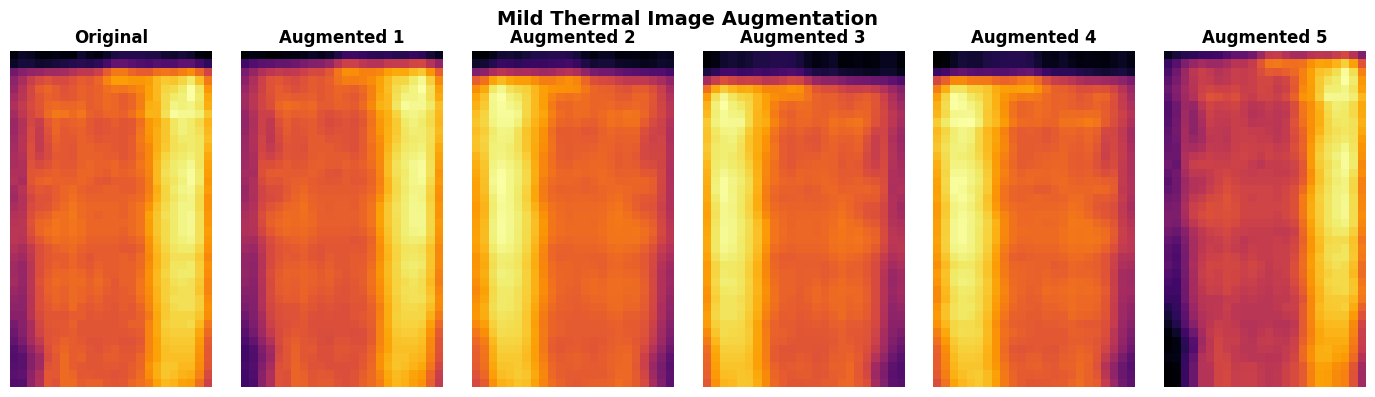

Figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\11_mild_thermal_augmentation.png


In [40]:
original_image = sample_images[0]

augmented_examples = [
    thermal_augmentation(
        tf.expand_dims(original_image, axis=0),
        training=True
    )[0].numpy().squeeze()
    for _ in range(5)
]

fig, axes = plt.subplots(1, 6, figsize=(14, 4))

axes[0].imshow(original_image.numpy().squeeze(), cmap="inferno")
axes[0].set_title("Original")
axes[0].axis("off")

for index, augmented_image in enumerate(augmented_examples, start=1):
    axes[index].imshow(augmented_image, cmap="inferno")
    axes[index].set_title(f"Augmented {index}")
    axes[index].axis("off")

plt.suptitle(
    "Mild Thermal Image Augmentation",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

figure_path = FIGURES_DIR / "11_mild_thermal_augmentation.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path.resolve())

In [41]:
tf.keras.backend.clear_session()

improved_binary_cnn = Sequential([
    Input(shape=INPUT_SHAPE),

    thermal_augmentation,

    Conv2D(16, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    ReLU(),

    Conv2D(96, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    ReLU(),

    GlobalAveragePooling2D(),

    Dense(64, activation="relu"),
    Dropout(0.40),

    Dense(1, activation="sigmoid")
])

improved_binary_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

improved_binary_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ thermal_augmentation            │ (None, 40, 24, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 24, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 24, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 40, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 12, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 12, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 20, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 6, 64)      │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 6, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 10, 6, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 6, 96)      │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 6, 96)      │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 10, 6, 96)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,585 (334.32 KB)

 Trainable params: 85,169 (332.69 KB)

 Non-trainable params: 416 (1.62 KB)

In [42]:
improved_binary_callbacks = [
    ModelCheckpoint(
        filepath=IMPROVED_BINARY_MODEL_PATH,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Improved model callbacks prepared successfully.")

Improved model callbacks prepared successfully.


In [43]:
improved_binary_history = improved_binary_cnn.fit(
    binary_train_ds,
    validation_data=binary_validation_ds,
    epochs=IMPROVED_MAX_EPOCHS,
    callbacks=improved_binary_callbacks,
    verbose=1
)

Epoch 1/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6769 - auc: 0.7388 - loss: 0.5914 - precision: 0.6923 - recall: 0.6698
Epoch 1: val_auc improved from None to 0.54831, saving model to c:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\models\binary_cnn_improved.keras

Epoch 1: finished saving model to c:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\models\binary_cnn_improved.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.7303 - auc: 0.8021 - loss: 0.5332 - precision: 0.7622 - recall: 0.6694 - val_accuracy: 0.5000 - val_auc: 0.5483 - val_loss: 1.1058 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7787 - auc: 0.8450 - loss: 0.4671 - precision: 0.8394 - recall: 0.6874
Epoch 2: val_auc improved from 0.54831 to 0

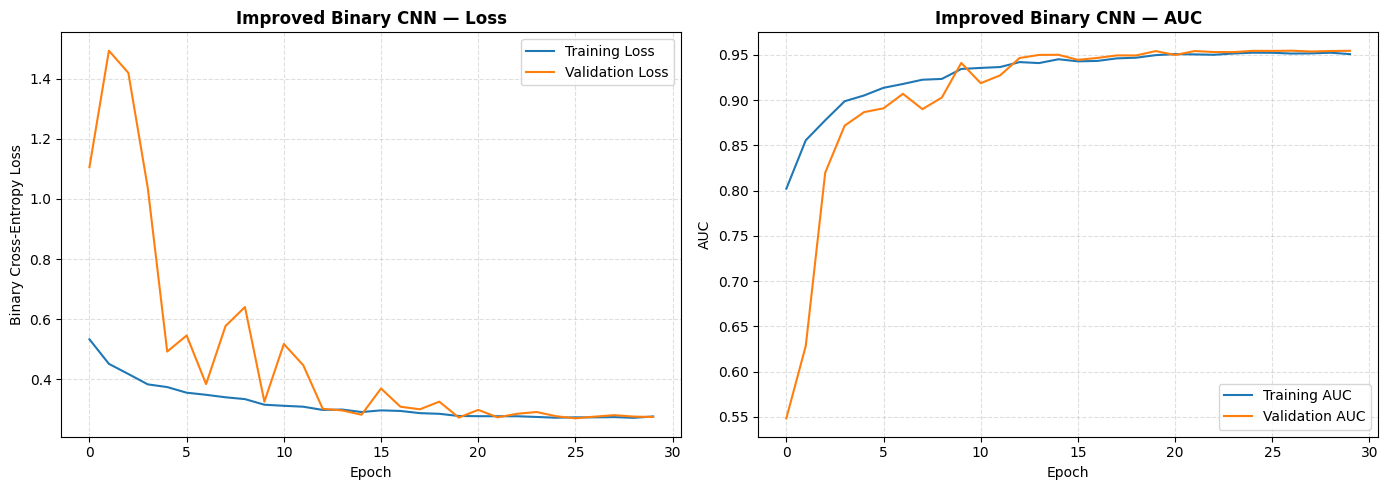

Training figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\12_improved_binary_training_history.png


In [44]:

improved_history_df = pd.DataFrame(improved_binary_history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(improved_history_df["loss"], label="Training Loss")
axes[0].plot(improved_history_df["val_loss"], label="Validation Loss")
axes[0].set_title("Improved Binary CNN — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.4)

axes[1].plot(improved_history_df["auc"], label="Training AUC")
axes[1].plot(improved_history_df["val_auc"], label="Validation AUC")
axes[1].set_title("Improved Binary CNN — AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.4)

plt.tight_layout()

figure_path = FIGURES_DIR / "12_improved_binary_training_history.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

history_path = METRICS_DIR / "improved_binary_training_history.csv"
improved_history_df.to_csv(history_path, index=False)

print("Training figure saved to:")
print(figure_path.resolve())

In [45]:

best_improved_binary_cnn = tf.keras.models.load_model(
    IMPROVED_BINARY_MODEL_PATH
)

y_validation_true = validation_df["is_anomaly"].values

y_validation_probability = (
    best_improved_binary_cnn
    .predict(binary_validation_ds, verbose=0)
    .ravel()
)

validation_precision, validation_recall, thresholds = precision_recall_curve(
    y_validation_true,
    y_validation_probability
)

beta = 2

f2_scores = (
    (1 + beta ** 2) *
    validation_precision[:-1] *
    validation_recall[:-1]
) / (
    beta ** 2 * validation_precision[:-1] +
    validation_recall[:-1] +
    1e-8
)

best_threshold_index = np.argmax(f2_scores)
selected_threshold = thresholds[best_threshold_index]

print("VALIDATION-BASED THRESHOLD SELECTION")
print("-" * 45)
print(f"Selected threshold: {selected_threshold:.4f}")
print(f"Validation precision at selected threshold: "
      f"{validation_precision[best_threshold_index]:.4f}")
print(f"Validation recall at selected threshold: "
      f"{validation_recall[best_threshold_index]:.4f}")
print(f"Validation F2-score at selected threshold: "
      f"{f2_scores[best_threshold_index]:.4f}")

VALIDATION-BASED THRESHOLD SELECTION
---------------------------------------------
Selected threshold: 0.1630
Validation precision at selected threshold: 0.8187
Validation recall at selected threshold: 0.9420
Validation F2-score at selected threshold: 0.9144


In [46]:

def evaluate_binary_predictions(y_true, probabilities, threshold, model_name):
    predictions = (probabilities >= threshold).astype(int)

    return {
        "Experiment": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1_Score": f1_score(y_true, predictions, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "False_Negatives": int(
            ((y_true == 1) & (predictions == 0)).sum()
        ),
        "False_Positives": int(
            ((y_true == 0) & (predictions == 1)).sum()
        )
    }


y_improved_test_probability = (
    best_improved_binary_cnn
    .predict(binary_test_ds, verbose=0)
    .ravel()
)

baseline_comparison_row = evaluate_binary_predictions(
    y_true_binary,
    y_probability_binary,
    threshold=0.50,
    model_name="Binary CNN Baseline"
)

improved_standard_row = evaluate_binary_predictions(
    y_true_binary,
    y_improved_test_probability,
    threshold=0.50,
    model_name="Improved Binary CNN — Threshold 0.50"
)

improved_selected_row = evaluate_binary_predictions(
    y_true_binary,
    y_improved_test_probability,
    threshold=selected_threshold,
    model_name="Improved Binary CNN — Validation F2 Threshold"
)

binary_experiment_comparison = pd.DataFrame([
    baseline_comparison_row,
    improved_standard_row,
    improved_selected_row
])

binary_experiment_comparison.round(4)

,Experiment,Threshold,Accuracy,Precision,Recall,F1_Score,ROC_AUC,False_Negatives,False_Positives
0,Binary CNN Baseline,0.500,0.8220,0.9032,0.7213,0.8021,0.9075,418,116
1,Improved Binary CNN — Threshold 0.50,0.500,0.8943,0.9404,0.8420,0.8885,0.9556,237,80
2,Improved Binary CNN — Validation F2 Threshold,0.163,0.8617,0.8145,0.9367,0.8713,0.9556,95,320


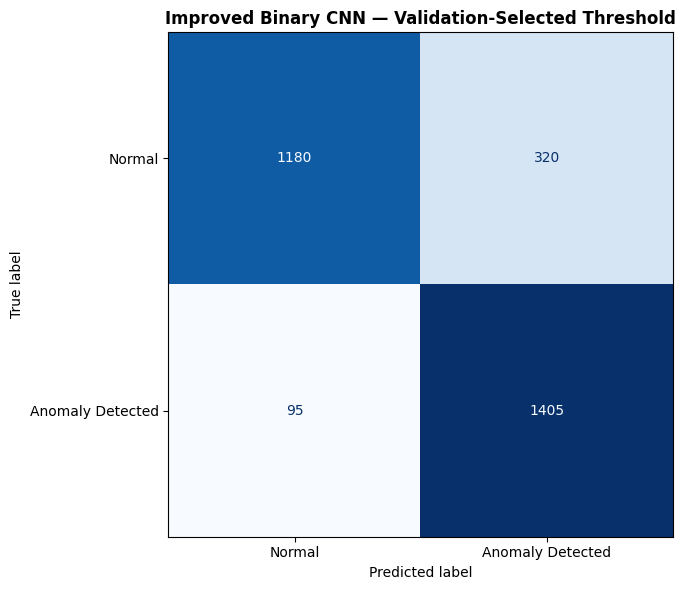

Confusion matrix saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\13_improved_binary_confusion_matrix.png

Comparison table saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\metrics\binary_experiment_comparison.csv


In [47]:

y_improved_selected_pred = (
    y_improved_test_probability >= selected_threshold
).astype(int)

improved_confusion_matrix = confusion_matrix(
    y_true_binary,
    y_improved_selected_pred
)

fig, ax = plt.subplots(figsize=(7, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix=improved_confusion_matrix,
    display_labels=["Normal", "Anomaly Detected"]
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Improved Binary CNN — Validation-Selected Threshold"
)

plt.tight_layout()

figure_path = FIGURES_DIR / "13_improved_binary_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

comparison_path = METRICS_DIR / "binary_experiment_comparison.csv"
binary_experiment_comparison.to_csv(comparison_path, index=False)

print("Confusion matrix saved to:")
print(figure_path.resolve())

print("\nComparison table saved to:")
print(comparison_path.resolve())

## Experiment 2 Results and Binary Model Selection

The improved binary CNN achieved substantially better performance than the initial baseline model.

| Model Configuration | Accuracy | Precision | Recall | F1-score | ROC-AUC | False Negatives | False Positives |
|---|---:|---:|---:|---:|---:|---:|---:|
| Binary CNN Baseline — Threshold 0.50 | 0.8220 | 0.9032 | 0.7213 | 0.8021 | 0.9075 | 418 | 116 |
| Improved Binary CNN — Threshold 0.50 | **0.8943** | **0.9404** | 0.8420 | **0.8885** | **0.9556** | 237 | **80** |
| Improved Binary CNN — Validation F2 Threshold | 0.8617 | 0.8145 | **0.9367** | 0.8713 | **0.9556** | **95** | 320 |

## Interpretation

The improved architecture substantially increased model quality. At the standard threshold of 0.50, it improved accuracy, F1-score and ROC-AUC while reducing both false negatives and false positives compared with the baseline.

The validation-selected F2 threshold produced a different operational behavior. It reduced the number of missed anomalous modules from 418 in the baseline model to only 95, representing a reduction of approximately 77%. Its anomaly recall increased to 93.67%.

This improvement comes with a trade-off: the number of normal modules flagged for inspection increased to 320. In a screening scenario, this trade-off can be acceptable because a false alarm leads to additional inspection, whereas a false negative may cause a defective module to remain unnoticed.

## Selected Binary Model for the Final Prototype

Two interpretations of the improved model will be retained:

- the standard threshold of 0.50 represents the best general-purpose binary classifier;
- the validation-selected F2 threshold will be used in the final SolarMedic AI screening workflow because it prioritizes anomaly detection recall.

The next experiment addresses the more difficult task of diagnosing the specific anomaly category.

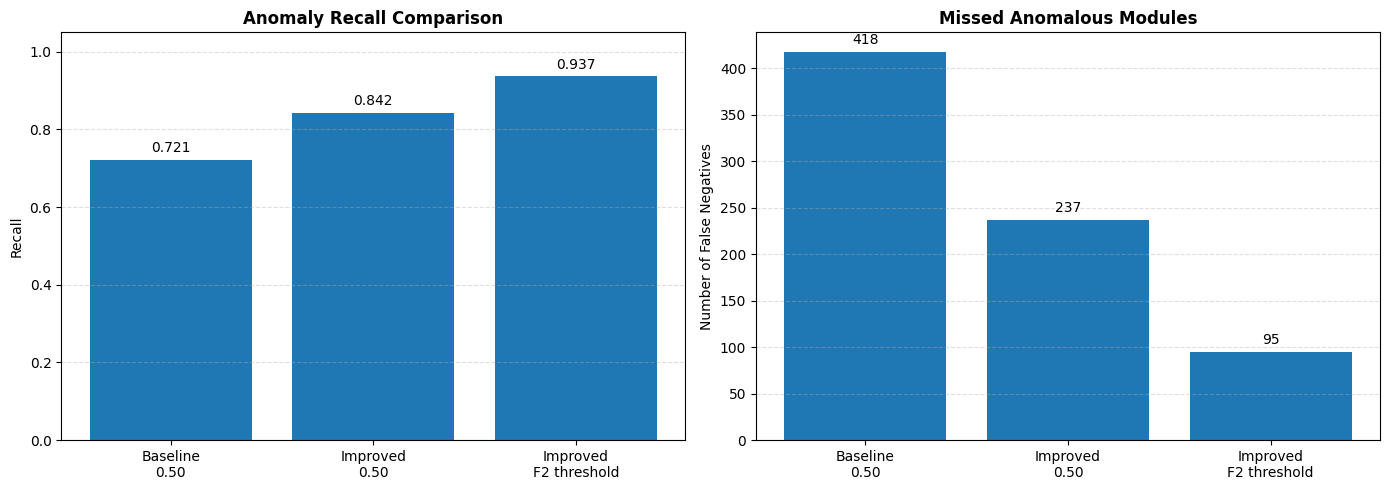

Figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\14_binary_model_comparison.png


In [49]:

comparison_plot_data = binary_experiment_comparison.copy()

comparison_plot_data["Short Name"] = [
    "Baseline\n0.50",
    "Improved\n0.50",
    "Improved\nF2 threshold"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars_recall = axes[0].bar(
    comparison_plot_data["Short Name"],
    comparison_plot_data["Recall"]
)

axes[0].set_title("Anomaly Recall Comparison")
axes[0].set_ylabel("Recall")
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars_recall:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.3f}",
        ha="center"
    )

bars_fn = axes[1].bar(
    comparison_plot_data["Short Name"],
    comparison_plot_data["False_Negatives"]
)

axes[1].set_title("Missed Anomalous Modules")
axes[1].set_ylabel("Number of False Negatives")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars_fn:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{int(bar.get_height())}",
        ha="center"
    )

plt.tight_layout()

figure_path = FIGURES_DIR / "14_binary_model_comparison.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path.resolve())

In [50]:

import json

binary_screening_configuration = {
    "selected_model": "Improved Binary CNN",
    "model_path": str(IMPROVED_BINARY_MODEL_PATH),
    "general_purpose_threshold": 0.50,
    "screening_threshold": float(selected_threshold),
    "threshold_selection_method": "Validation F2-score optimization",
    "test_recall_at_screening_threshold": float(
        improved_selected_row["Recall"]
    ),
    "test_false_negatives_at_screening_threshold": int(
        improved_selected_row["False_Negatives"]
    )
}

configuration_path = METRICS_DIR / "binary_screening_configuration.json"

with open(configuration_path, "w", encoding="utf-8") as configuration_file:
    json.dump(
        binary_screening_configuration,
        configuration_file,
        indent=4
    )

print("Binary screening configuration saved successfully.")
print("Location:", configuration_path.resolve())
print("\nSelected screening threshold:", round(selected_threshold, 4))

Binary screening configuration saved successfully.
Location: C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\metrics\binary_screening_configuration.json

Selected screening threshold: 0.163


# 13. Experiment 3 — Multi-Class Anomaly Diagnosis CNN

## From Binary Triage to Technical Diagnosis

The SolarMedic AI workflow is designed as a hierarchical system.

The first stage has already been developed:

> Is the photovoltaic module normal or anomalous?

The second stage addresses a different question:

> If a module is considered anomalous, what is the most probable anomaly category?

For this reason, the detailed diagnosis model is trained only on anomalous samples. The `No-Anomaly` class is excluded from this stage because it is already handled by the binary triage model.

## Diagnosis Classes

The diagnosis model predicts one of eleven anomaly categories:

- `Cell`
- `Cell-Multi`
- `Cracking`
- `Diode`
- `Diode-Multi`
- `Hot-Spot`
- `Hot-Spot-Multi`
- `Offline-Module`
- `Shadowing`
- `Soiling`
- `Vegetation`

## Motivation

This design is more realistic than training a single twelve-class classifier:

- the first model acts as a screening tool;
- the second model specializes in identifying anomaly subtypes;
- the dominant normal class no longer overwhelms the diagnosis task;
- the remaining imbalance between anomaly classes will be addressed using class weights.

## Evaluation Metrics

Since the anomaly classes remain imbalanced, diagnosis quality will be measured using:

- accuracy;
- macro F1-score;
- weighted F1-score;
- per-class precision and recall;
- confusion matrix.

Macro F1-score is particularly important because it gives the rare anomaly classes equal importance during evaluation.

In [51]:

anomaly_train_df = train_df[
    train_df["anomaly_class"] != "No-Anomaly"
].copy()

anomaly_validation_df = validation_df[
    validation_df["anomaly_class"] != "No-Anomaly"
].copy()

anomaly_test_df = test_df[
    test_df["anomaly_class"] != "No-Anomaly"
].copy()

diagnosis_classes = sorted(
    anomaly_train_df["anomaly_class"].unique().tolist()
)

class_to_index = {
    class_name: index
    for index, class_name in enumerate(diagnosis_classes)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

for subset in [
    anomaly_train_df,
    anomaly_validation_df,
    anomaly_test_df
]:
    subset["diagnosis_target"] = subset["anomaly_class"].map(class_to_index)

print("ANOMALY DIAGNOSIS DATASET")
print("-" * 40)
print("Number of diagnosis classes:", len(diagnosis_classes))
print("Diagnosis classes:", diagnosis_classes)
print()
print("Training anomaly images:", len(anomaly_train_df))
print("Validation anomaly images:", len(anomaly_validation_df))
print("Test anomaly images:", len(anomaly_test_df))

assert len(diagnosis_classes) == 11
assert len(anomaly_train_df) == 7000
assert len(anomaly_validation_df) == 1500
assert len(anomaly_test_df) == 1500

pd.crosstab(
    anomaly_train_df["anomaly_class"],
    columns="Training Images"
).sort_values("Training Images", ascending=False)

ANOMALY DIAGNOSIS DATASET
----------------------------------------
Number of diagnosis classes: 11
Diagnosis classes: ['Cell', 'Cell-Multi', 'Cracking', 'Diode', 'Diode-Multi', 'Hot-Spot', 'Hot-Spot-Multi', 'Offline-Module', 'Shadowing', 'Soiling', 'Vegetation']

Training anomaly images: 7000
Validation anomaly images: 1500
Test anomaly images: 1500


col_0,Training Images
anomaly_class,
Cell,1314
Vegetation,1147
Diode,1049
Cell-Multi,902
Shadowing,739
Cracking,658
Offline-Module,579
Hot-Spot,174
Hot-Spot-Multi,172


In [52]:

from sklearn.utils.class_weight import compute_class_weight

diagnosis_class_indices = np.array(
    sorted(anomaly_train_df["diagnosis_target"].unique())
)

computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=diagnosis_class_indices,
    y=anomaly_train_df["diagnosis_target"].values
)

diagnosis_class_weights = {
    int(class_index): float(weight)
    for class_index, weight in zip(
        diagnosis_class_indices,
        computed_weights
    )
}

class_weight_table = pd.DataFrame({
    "Class Index": diagnosis_class_indices,
    "Anomaly Class": [
        index_to_class[int(class_index)]
        for class_index in diagnosis_class_indices
    ],
    "Training Images": [
        int(
            (anomaly_train_df["diagnosis_target"] == class_index).sum()
        )
        for class_index in diagnosis_class_indices
    ],
    "Class Weight": [
        diagnosis_class_weights[int(class_index)]
        for class_index in diagnosis_class_indices
    ]
}).sort_values("Training Images", ascending=False)

class_weight_table

,Class Index,Anomaly Class,Training Images,Class Weight
0,0,Cell,1314,0.484295
10,10,Vegetation,1147,0.554807
3,3,Diode,1049,0.606638
1,1,Cell-Multi,902,0.705503
8,8,Shadowing,739,0.861115
2,2,Cracking,658,0.967118
7,7,Offline-Module,579,1.099074
5,5,Hot-Spot,174,3.657262
6,6,Hot-Spot-Multi,172,3.699789
9,9,Soiling,143,4.450095


## Handling Imbalance in the Diagnosis Task

Although the normal class has been removed from the second stage, the eleven anomaly classes remain imbalanced.

For example, frequent anomaly classes such as `Cell` contain considerably more images than rare categories such as `Diode-Multi`, `Soiling` or `Hot-Spot-Multi`.

To reduce the risk that the model focuses primarily on frequent anomaly categories, balanced class weights are applied during training. This means that classification errors on rare classes contribute more strongly to the training loss.

The effect of this decision will be evaluated using macro F1-score and per-class recall rather than accuracy alone.

In [53]:


DIAGNOSIS_BATCH_SIZE = 64
NUMBER_OF_DIAGNOSIS_CLASSES = len(diagnosis_classes)

def load_diagnosis_image(image_path, label):
    """
    Loads and normalizes one infrared image for multi-class diagnosis.
    """
    image = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image, channels=1)
    image = tf.image.convert_image_dtype(image, tf.float32)

    image.set_shape([IMG_HEIGHT, IMG_WIDTH, CHANNELS])

    label = tf.cast(label, tf.int32)

    return image, label


def create_diagnosis_dataset(dataframe, training=False):
    """
    Creates a TensorFlow dataset for anomaly-category diagnosis.
    """
    image_paths = dataframe["filepath"].astype(str).values
    labels = dataframe["diagnosis_target"].astype("int32").values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    dataset = dataset.map(
        load_diagnosis_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.cache()

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(DIAGNOSIS_BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


diagnosis_train_ds = create_diagnosis_dataset(
    anomaly_train_df,
    training=True
)

diagnosis_validation_ds = create_diagnosis_dataset(
    anomaly_validation_df,
    training=False
)

diagnosis_test_ds = create_diagnosis_dataset(
    anomaly_test_df,
    training=False
)

sample_diagnosis_images, sample_diagnosis_labels = next(
    iter(diagnosis_train_ds)
)

print("Diagnosis datasets created successfully.")
print("Image batch shape:", sample_diagnosis_images.shape)
print("Label batch shape:", sample_diagnosis_labels.shape)
print("Number of diagnosis classes:", NUMBER_OF_DIAGNOSIS_CLASSES)

Diagnosis datasets created successfully.
Image batch shape: (64, 40, 24, 1)
Label batch shape: (64,)
Number of diagnosis classes: 11


In [54]:

DIAGNOSIS_MAX_EPOCHS = 35
DIAGNOSIS_MODEL_PATH = MODELS_DIR / "anomaly_diagnosis_cnn.keras"

diagnosis_augmentation = Sequential(
    [
        RandomFlip("horizontal"),
        RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="nearest"
        ),
        RandomContrast(0.10)
    ],
    name="diagnosis_augmentation"
)

tf.keras.backend.clear_session()

anomaly_diagnosis_cnn = Sequential([
    Input(shape=INPUT_SHAPE),

    diagnosis_augmentation,

    Conv2D(16, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    ReLU(),

    Conv2D(96, (3, 3), padding="same", use_bias=False),
    BatchNormalization(),
    ReLU(),

    GlobalAveragePooling2D(),

    Dense(96, activation="relu"),
    Dropout(0.45),

    Dense(
        NUMBER_OF_DIAGNOSIS_CLASSES,
        activation="softmax"
    )
])

anomaly_diagnosis_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

anomaly_diagnosis_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ diagnosis_augmentation          │ (None, 40, 24, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 24, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 24, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 40, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 12, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 12, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 20, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 6, 64)      │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 6, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 10, 6, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 6, 96)      │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 6, 96)      │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 10, 6, 96)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,067 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,691 (350.36 KB)

 Trainable params: 89,275 (348.73 KB)

 Non-trainable params: 416 (1.62 KB)

In [55]:

diagnosis_callbacks = [
    ModelCheckpoint(
        filepath=DIAGNOSIS_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

diagnosis_history = anomaly_diagnosis_cnn.fit(
    diagnosis_train_ds,
    validation_data=diagnosis_validation_ds,
    epochs=DIAGNOSIS_MAX_EPOCHS,
    class_weight=diagnosis_class_weights,
    callbacks=diagnosis_callbacks,
    verbose=1
)

Epoch 1/35
107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1624 - loss: 2.3133
Epoch 1: val_loss improved from None to 2.41109, saving model to c:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\models\anomaly_diagnosis_cnn.keras

Epoch 1: finished saving model to c:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\models\anomaly_diagnosis_cnn.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.1971 - loss: 2.2442 - val_accuracy: 0.1640 - val_loss: 2.4111 - learning_rate: 0.0010
Epoch 2/35
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2799 - loss: 2.0258
Epoch 2: val_loss did not improve from 2.41109
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2957 - loss: 1.9505 - val_accuracy: 0.0613 - val_loss: 3.1215 - learning_rate: 0.0010
Epoch 3/35
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3397 -

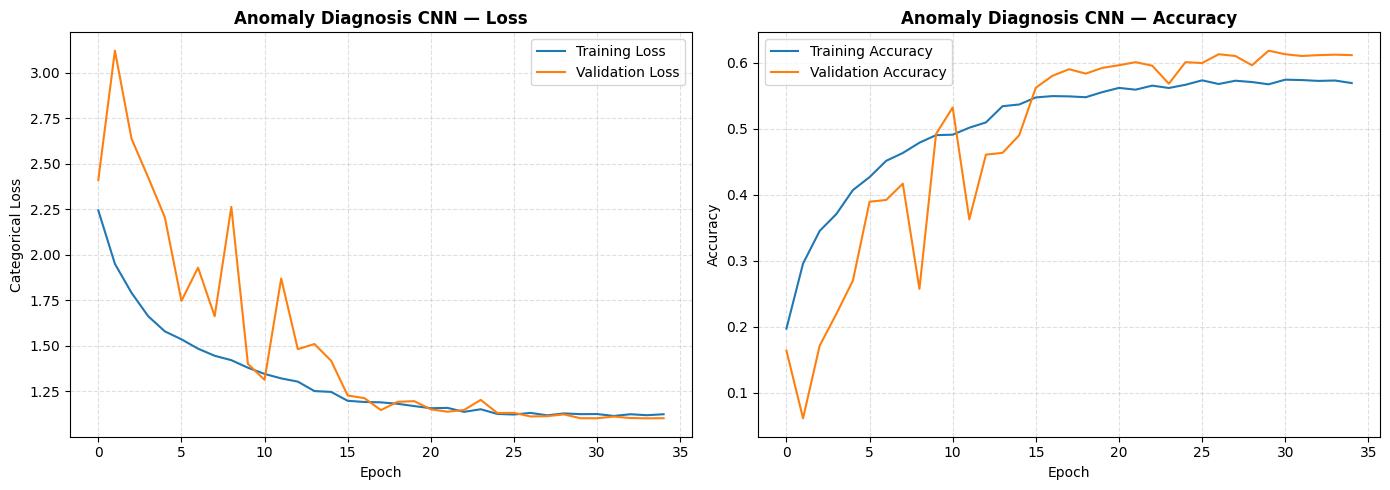

Training figure saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\15_diagnosis_cnn_training_history.png


In [56]:

diagnosis_history_df = pd.DataFrame(diagnosis_history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    diagnosis_history_df["loss"],
    label="Training Loss"
)
axes[0].plot(
    diagnosis_history_df["val_loss"],
    label="Validation Loss"
)
axes[0].set_title("Anomaly Diagnosis CNN — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Categorical Loss")
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.4)

axes[1].plot(
    diagnosis_history_df["accuracy"],
    label="Training Accuracy"
)
axes[1].plot(
    diagnosis_history_df["val_accuracy"],
    label="Validation Accuracy"
)
axes[1].set_title("Anomaly Diagnosis CNN — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.4)

plt.tight_layout()

figure_path = FIGURES_DIR / "15_diagnosis_cnn_training_history.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

history_path = METRICS_DIR / "diagnosis_cnn_training_history.csv"
diagnosis_history_df.to_csv(history_path, index=False)

print("Training figure saved to:")
print(figure_path.resolve())

In [57]:


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

best_diagnosis_cnn = tf.keras.models.load_model(
    DIAGNOSIS_MODEL_PATH
)

y_diagnosis_true = anomaly_test_df[
    "diagnosis_target"
].values

y_diagnosis_probability = best_diagnosis_cnn.predict(
    diagnosis_test_ds,
    verbose=0
)

y_diagnosis_pred = np.argmax(
    y_diagnosis_probability,
    axis=1
)

diagnosis_accuracy = accuracy_score(
    y_diagnosis_true,
    y_diagnosis_pred
)

diagnosis_macro_f1 = f1_score(
    y_diagnosis_true,
    y_diagnosis_pred,
    average="macro"
)

diagnosis_weighted_f1 = f1_score(
    y_diagnosis_true,
    y_diagnosis_pred,
    average="weighted"
)

diagnosis_report = classification_report(
    y_diagnosis_true,
    y_diagnosis_pred,
    labels=list(range(NUMBER_OF_DIAGNOSIS_CLASSES)),
    target_names=diagnosis_classes,
    output_dict=True,
    zero_division=0
)

diagnosis_report_df = pd.DataFrame(
    diagnosis_report
).transpose()

print("ANOMALY DIAGNOSIS CNN — TEST RESULTS")
print("-" * 45)
print(f"Accuracy:    {diagnosis_accuracy:.4f}")
print(f"Macro F1:    {diagnosis_macro_f1:.4f}")
print(f"Weighted F1: {diagnosis_weighted_f1:.4f}")

diagnosis_report_df

ANOMALY DIAGNOSIS CNN — TEST RESULTS
---------------------------------------------
Accuracy:    0.5927
Macro F1:    0.5520
Weighted F1: 0.5973


,precision,recall,f1-score,support
Cell,0.557447,0.466192,0.507752,281.000000
Cell-Multi,0.480769,0.259067,0.336700,193.000000
Cracking,0.708029,0.687943,0.697842,141.000000
Diode,0.938679,0.884444,0.910755,225.000000
Diode-Multi,0.727273,0.923077,0.813559,26.000000
Hot-Spot,0.204545,0.486486,0.288000,37.000000
Hot-Spot-Multi,0.250000,0.432432,0.316832,37.000000
Offline-Module,0.577465,0.661290,0.616541,124.000000
Shadowing,0.654762,0.691824,0.672783,159.000000
Soiling,0.209302,0.580645,0.307692,31.000000


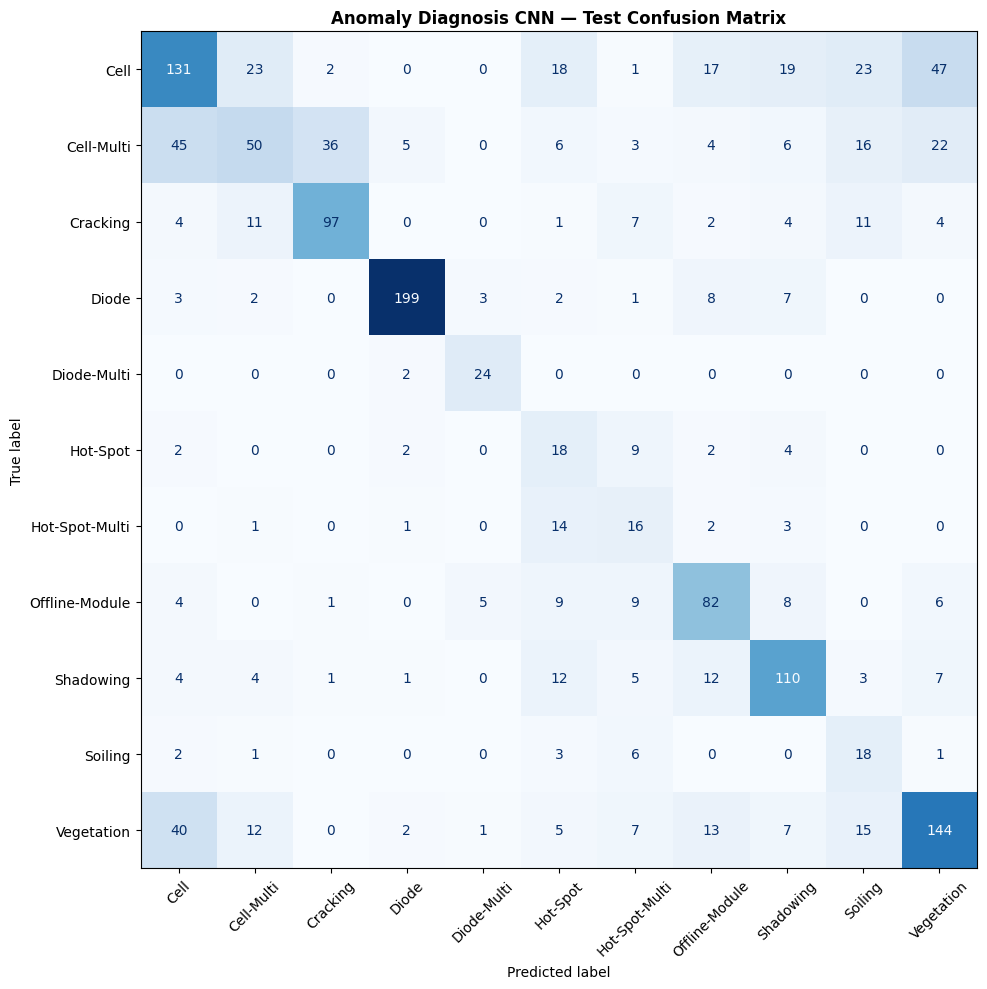

Confusion matrix saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\figures\16_diagnosis_confusion_matrix.png

Classification report saved to:
C:\Users\Carla Bozintan\OneDrive - Technical University of Cluj-Napoca\Desktop\Facultate\Facultate\An3\SI\solar-medic-project\outputs\metrics\diagnosis_classification_report.csv


In [58]:

diagnosis_confusion_matrix = confusion_matrix(
    y_diagnosis_true,
    y_diagnosis_pred,
    labels=list(range(NUMBER_OF_DIAGNOSIS_CLASSES))
)

fig, ax = plt.subplots(figsize=(12, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix=diagnosis_confusion_matrix,
    display_labels=diagnosis_classes
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    xticks_rotation=45
)

ax.set_title("Anomaly Diagnosis CNN — Test Confusion Matrix")

plt.tight_layout()

figure_path = FIGURES_DIR / "16_diagnosis_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

report_path = METRICS_DIR / "diagnosis_classification_report.csv"
diagnosis_report_df.to_csv(report_path)

print("Confusion matrix saved to:")
print(figure_path.resolve())

print("\nClassification report saved to:")
print(report_path.resolve())

# 14. Final Model Selection and Diagnosis Analysis

The final SolarMedic AI prototype combines two neural-network components:

1. an improved binary CNN for screening photovoltaic modules;
2. an anomaly diagnosis CNN for predicting the probable defect type of suspicious modules.

## Binary Screening Model

The improved binary CNN significantly outperformed the baseline model.

| Model Configuration | Accuracy | Recall — Anomaly | F1-score | ROC-AUC | Missed Anomalies |
|---|---:|---:|---:|---:|---:|
| Binary CNN Baseline | 0.8220 | 0.7213 | 0.8021 | 0.9075 | 418 |
| Improved Binary CNN — Threshold 0.50 | **0.8943** | 0.8420 | **0.8885** | **0.9556** | 237 |
| Improved Binary CNN — Recall-Oriented Threshold | 0.8617 | **0.9367** | 0.8713 | **0.9556** | **95** |

The recall-oriented threshold is selected for the final screening workflow because it reduces missed anomalous modules from 418 to 95. Although it generates more false alarms, this behavior is appropriate for an inspection-support system, where missing a defective module is more problematic than recommending an additional inspection.

## Anomaly Diagnosis Model

The second-stage diagnosis CNN was trained only on anomalous modules and predicts one of eleven anomaly categories.

| Metric | Test Result |
|---|---:|
| Accuracy | 0.5927 |
| Macro F1-score | 0.5520 |
| Weighted F1-score | 0.5973 |

The diagnosis task is considerably more difficult than binary screening. The model performs particularly well for `Diode`, `Diode-Multi`, `Cracking` and `Shadowing`, while classes such as `Hot-Spot`, `Hot-Spot-Multi`, `Soiling` and `Cell-Multi` remain difficult to distinguish.

The confusion matrix suggests that visually related thermal patterns are often confused, for example:

- `Cell-Multi` with `Cell`;
- `Hot-Spot-Multi` with `Hot-Spot`;
- `Cell` with `Vegetation`.

## Final System Interpretation

The final prototype should therefore be interpreted as:

- a strong screening tool for identifying suspicious modules;
- a decision-support tool for suggesting a probable anomaly type;
- not a fully autonomous industrial diagnostic system.

The workflow is:

1. predict whether the module should be flagged for inspection;
2. if flagged, predict the probable anomaly category;
3. convert the diagnosis into a demonstrative maintenance priority.

DEMONSTRATION 1 — ANOMALOUS MODULE



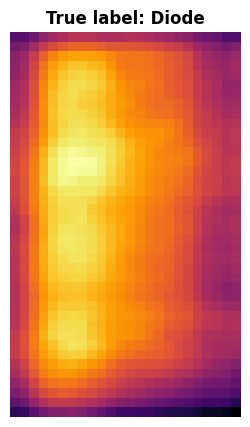

SOLARMEDIC AI — THERMAL INSPECTION REPORT
------------------------------------------------
True dataset label:     Diode
Screening status:       Anomaly Detected
Anomaly probability:    97.59%
Predicted diagnosis:    Diode
Diagnosis confidence:   77.89%
Maintenance priority:   High

Top diagnostic candidates:
1. Diode              77.89%
2. Hot-Spot           5.11%
3. Cell-Multi         3.70%


DEMONSTRATION 2 — NORMAL MODULE



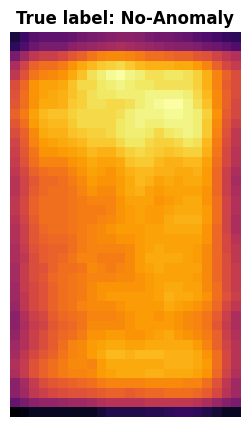

SOLARMEDIC AI — THERMAL INSPECTION REPORT
------------------------------------------------
True dataset label:     No-Anomaly
Screening status:       Normal
Anomaly probability:    11.24%
Predicted diagnosis:    No-Anomaly
Diagnosis confidence:   88.76%
Maintenance priority:   Low


In [59]:

final_screening_model = tf.keras.models.load_model(IMPROVED_BINARY_MODEL_PATH)
final_diagnosis_model = tf.keras.models.load_model(DIAGNOSIS_MODEL_PATH)

FINAL_SCREENING_THRESHOLD = float(selected_threshold)

def prepare_single_image(image_path):
    """Load and normalize one infrared image for inference."""
    image = tf.io.read_file(str(image_path))
    image = tf.io.decode_jpeg(image, channels=1)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.reshape(image, [IMG_HEIGHT, IMG_WIDTH, CHANNELS])
    return tf.expand_dims(image, axis=0)


def inspect_solar_module(sample_row):
    """
    Run the complete SolarMedic AI workflow for one test image.
    """
    image_path = sample_row["filepath"]
    true_label = sample_row["anomaly_class"]

    image_tensor = prepare_single_image(image_path)

    anomaly_probability = float(
        final_screening_model.predict(image_tensor, verbose=0)[0][0]
    )

    if anomaly_probability < FINAL_SCREENING_THRESHOLD:
        predicted_status = "Normal"
        predicted_diagnosis = "No-Anomaly"
        priority = "Low"
        diagnosis_confidence = 1 - anomaly_probability
        top_three = []

    else:
        predicted_status = "Anomaly Detected"

        diagnosis_probabilities = final_diagnosis_model.predict(
            image_tensor,
            verbose=0
        )[0]

        top_indices = np.argsort(diagnosis_probabilities)[::-1][:3]

        top_three = [
            (index_to_class[int(index)], float(diagnosis_probabilities[index]))
            for index in top_indices
        ]

        predicted_diagnosis = top_three[0][0]
        diagnosis_confidence = top_three[0][1]
        priority = priority_mapping[predicted_diagnosis]

    with Image.open(image_path) as image:
        plt.figure(figsize=(3, 5))
        plt.imshow(image, cmap="inferno")
        plt.title(f"True label: {true_label}")
        plt.axis("off")
        plt.show()

    print("SOLARMEDIC AI — THERMAL INSPECTION REPORT")
    print("-" * 48)
    print(f"True dataset label:     {true_label}")
    print(f"Screening status:       {predicted_status}")
    print(f"Anomaly probability:    {anomaly_probability:.2%}")
    print(f"Predicted diagnosis:    {predicted_diagnosis}")
    print(f"Diagnosis confidence:   {diagnosis_confidence:.2%}")
    print(f"Maintenance priority:   {priority}")

    if top_three:
        print("\nTop diagnostic candidates:")
        for rank, (class_name, probability) in enumerate(top_three, start=1):
            print(f"{rank}. {class_name:<18} {probability:.2%}")



anomaly_example = test_df[
    test_df["anomaly_class"] == "Diode"
].sample(1, random_state=SEED).iloc[0]

normal_example = test_df[
    test_df["anomaly_class"] == "No-Anomaly"
].sample(1, random_state=SEED).iloc[0]

print("DEMONSTRATION 1 — ANOMALOUS MODULE\n")
inspect_solar_module(anomaly_example)

print("\n" + "=" * 60 + "\n")
print("DEMONSTRATION 2 — NORMAL MODULE\n")
inspect_solar_module(normal_example)

# 15. Comparison with Literature and Related Work

Infrared inspection of photovoltaic modules is a relevant computer vision problem because thermal patterns may indicate operational anomalies that require maintenance attention.

The dataset used in this project, **Infrared Solar Modules**, was introduced by Millendorf et al. as a public benchmark containing 20,000 infrared module images with twelve labels: one normal class and eleven anomaly categories [1]. The dataset was designed to support research on automated analysis of real-world solar-farm infrared imagery.

The SolarMedic AI project follows the same general motivation, but introduces a hierarchical workflow:

1. binary screening of modules as `Normal` or `Anomaly Detected`;
2. diagnosis of the probable anomaly category only for suspicious modules;
3. assignment of a demonstrative maintenance priority.

This hierarchy is motivated by the experimental results obtained in this notebook. Binary anomaly screening was substantially more reliable than exact anomaly diagnosis:

| Task | Selected Model Result |
|---|---:|
| Binary screening ROC-AUC | 0.9556 |
| Binary screening anomaly recall | 0.9367 |
| Eleven-class diagnosis accuracy | 0.5927 |
| Eleven-class diagnosis macro F1-score | 0.5520 |

Related work has also investigated CNN-based inspection of photovoltaic modules from infrared imagery. Le et al. proposed deep learning methods for rapid anomaly detection using infrared images captured by aerial systems, emphasizing the practical value of automated thermal inspection [2].

A particularly important observation from more advanced research is that real deployment requires generalization across different photovoltaic plants. Bommes et al. investigated anomaly detection under domain shift, where training and evaluation data originate from different solar installations [3]. This is relevant to the present project because the available metadata does not provide plant-level identifiers; therefore, SolarMedic AI uses an image-level stratified split and should be interpreted as a controlled prototype rather than an industrially validated system.

## Comparison Summary

| Aspect | SolarMedic AI | Related Research Direction |
|---|---|---|
| Image modality | Infrared module images | Infrared photovoltaic inspection |
| Main task | Screening + diagnosis | Fault/anomaly detection |
| Model type | Custom CNN models | CNN / advanced representation learning |
| Practical output | Maintenance-priority prototype | Inspection support and deployment |
| Main limitation | Image-level evaluation and low resolution | Cross-site generalization and field deployment |

## References

[1] M. Millendorf et al., *Infrared Solar Module Dataset for Anomaly Detection*, AI for Earth Sciences Workshop, ICLR, 2020.

[2] M. Le et al., *Thermal Inspection of Photovoltaic Modules with Deep Learning*, Measurement, 2023.

[3] L. Bommes et al., *Anomaly Detection in IR Images of PV Modules Using Supervised Contrastive Learning*, 2021.

# 16. Final Conclusions, Limitations and Future Work

## Final Conclusions

This project developed **SolarMedic AI**, a hierarchical deep learning prototype for thermal inspection of photovoltaic modules.

The project started with exploratory analysis of 20,000 infrared images belonging to twelve module-condition classes. The analysis revealed two major challenges:

- the images have a very low resolution of only 24 × 40 pixels;
- the original diagnosis classes are strongly imbalanced.

Based on these findings, the project adopted a hierarchical workflow.

## Main Experimental Results

### Binary Screening

The first task distinguished normal modules from modules containing anomalies.

The initial binary CNN baseline achieved:

- accuracy: 0.8220;
- anomaly recall: 0.7213;
- ROC-AUC: 0.9075.

The improved binary CNN, using augmentation and a validation-selected recall-oriented threshold, achieved:

- anomaly recall: **0.9367**;
- ROC-AUC: **0.9556**;
- only **95 missed anomalous modules**, compared with 418 for the baseline.

This result demonstrates that deep learning can provide a useful first-stage screening mechanism for identifying modules that require further inspection.

### Detailed Anomaly Diagnosis

The second task attempted to distinguish between eleven anomaly categories.

The diagnosis CNN achieved:

- accuracy: **0.5927**;
- macro F1-score: **0.5520**;
- weighted F1-score: **0.5973**.

The model performed well for classes such as `Diode`, `Diode-Multi`, `Cracking` and `Shadowing`, but struggled with visually similar or rare classes such as `Hot-Spot`, `Hot-Spot-Multi`, `Soiling` and `Cell-Multi`.

## Final Prototype Interpretation

The final SolarMedic AI prototype is therefore best understood as:

- a strong screening system for identifying suspicious photovoltaic modules;
- a supporting tool for suggesting a probable anomaly type;
- a demonstrative system for assigning maintenance priority;
- not an autonomous replacement for expert inspection.

## Limitations

The project has several important limitations:

1. The infrared images are extremely small, limiting the visibility of fine defect details.
2. The anomaly classes are imbalanced, especially for rare categories.
3. The dataset split is image-based because plant-level identifiers are not available.
4. The maintenance-priority mapping is educational and not an official industrial standard.
5. The diagnosis model may confuse anomaly classes with similar thermal patterns.

## Future Work

Future improvements could include:

- evaluation on images from unseen photovoltaic plants;
- higher-resolution infrared imagery;
- incorporation of neighboring-panel context;
- comparison with transfer-learning or attention-based models;
- integration of thermal temperature measurements and geographic information;
- deployment in a drone-assisted solar-farm inspection dashboard.

## Final Statement

SolarMedic AI demonstrates that a carefully designed deep learning workflow can convert infrared imagery into useful inspection-support information. The project also shows that, while anomaly screening can be highly reliable, precise automatic diagnosis remains a more challenging task and should be communicated with appropriate uncertainty.